scratch pad for new program to align and coadd WFC images without using swarp

In [12]:
import os
import ccdproc as ccdp

In [8]:
imagedir='/home/rfinn/data/reduced/scratch-int-feb2019/attempt2/pointing149/'


In [9]:
homedir = os.getenv("HOME")
os.chdir(homedir+'/data/align-coadd-test/')

In [10]:
!ls

In [20]:
keys = ['naxis1', 'naxis2', 'imagetyp', 'filter', 'exptime','instrmnt']
ic = ccdp.ImageFileCollection(imagedir, keywords=keys, glob_include='WFC*.fits',glob_exclude='*test*.fit')

In [40]:
(ic.files_filtered(filter='Halpha'))

array(['WFC.Halpha.2019-02-09T06:09:48.8_1PA.fits',
       'WFC.Halpha.2019-02-09T06:09:48.8_2PA.fits',
       'WFC.Halpha.2019-02-09T06:09:48.8_3PA.fits',
       'WFC.Halpha.2019-02-09T06:09:48.8_4PA.fits',
       'WFC.Halpha.2019-02-09T06:13:37.8_1PA.fits',
       'WFC.Halpha.2019-02-09T06:13:37.8_2PA.fits',
       'WFC.Halpha.2019-02-09T06:13:37.8_3PA.fits',
       'WFC.Halpha.2019-02-09T06:13:37.8_4PA.fits',
       'WFC.Halpha.2019-02-09T06:17:35.8_1PA.fits',
       'WFC.Halpha.2019-02-09T06:17:35.8_2PA.fits',
       'WFC.Halpha.2019-02-09T06:17:35.8_3PA.fits',
       'WFC.Halpha.2019-02-09T06:17:35.8_4PA.fits',
       'WFC.Halpha.2019-02-09T06:21:22.7_1PA.fits',
       'WFC.Halpha.2019-02-09T06:21:22.7_2PA.fits',
       'WFC.Halpha.2019-02-09T06:21:22.7_3PA.fits',
       'WFC.Halpha.2019-02-09T06:21:22.7_4PA.fits',
       'WFC.Halpha.2019-02-09T06:25:21.9_1PA.fits',
       'WFC.Halpha.2019-02-09T06:25:21.9_2PA.fits',
       'WFC.Halpha.2019-02-09T06:25:21.9_3PA.fits',
       'WFC.

In [19]:
!gethead WFC.Halpha.2019-02-09T06:09:48.8_1PA.fits

GETHEAD: no files specified


In [27]:
maskdict = {"'INTWFC{}':mask{}".format(i,i) for i in range(1,5)}

In [32]:
t='filemane.fits'
os.path.basename(t)

'filemane.fits'

In [45]:
set(ic.summary['filter'])

{'Halpha', 'r'}

# Trying to use montage



In [46]:
from MontagePy.main    import *
from MontagePy.archive import *

from IPython.display import Image


In [51]:
os.chdir('/home/rfinn/data/reduced/scratch-int-feb2019/attempt2/pointing149')

In [70]:
test = mImgtbl(os.getcwd(),'wfcimages.tbl')

In [72]:
myhdr = mMakeHdr('wfcimages.tbl','wfcimages.hdr')

In [74]:
rtn = mProjExec(os.getcwd(),'wfcimages.tbl','wfcimages.hdr',projdir="projected",quickMode=True)

{'status': '0', 'count': 62, 'failed': 0, 'nooverlap': 0}

In [75]:
mImgtbl("projected","pimages.tbl")

{'status': '0', 'count': 62, 'badfits': 0, 'badwcs': 0}

In [76]:
rtn = mOverlaps("pimages.tbl","diffs.tbl")

In [77]:
rtn = mDiffFitExec("projected",'diffs.tbl',"wfcimages.hdr","diffs","fits.tbl")

In [ ]:
rtn = mBgModel("pimages.tbl","fits.tbl","corrections.tbl")

# Reconstructing Coadds in Jan 2026!

In [1]:
import os
from astropy.io import fits

In [2]:
os.chdir('/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all')

In [3]:
os.chdir('pointing002')

In [13]:
# checking catalog for instrument keyword
catfilename = "WFC.Ha6657.2019-05-31T00:29:35.9_4PA.cat"
catfilename = "WFC.r.2019-05-30T23:47:11.0_4PA.cat"
cat = fits.open(catfilename)

In [14]:
cat[0].header

SIMPLE  =                    T / This is a FITS file                            
BITPIX  =                    8 /                                                
NAXIS   =                    0 /                                                
EXTEND  =                    T / This file may contain FITS extensions          

In [15]:
cat[1].header

XTENSION= 'BINTABLE'           / THIS IS A BINARY TABLE (FROM THE LDACTOOLS)    
BITPIX  =                    8 /                                                
NAXIS   =                    2 /                                                
NAXIS1  =                11200 / BYTES PER ROW                                  
NAXIS2  =                    1 / NUMBER OF ROWS                                 
PCOUNT  =                    0 / RANDOM PARAMETER COUNT                         
GCOUNT  =                    1 / GROUP COUNT                                    
TFIELDS =                    1 / FIELDS PER ROWS                                
EXTNAME = 'LDAC_IMHEAD'        / TABLE NAME                                     
TTYPE1  = 'Field Header Card'                                                   
TFORM1  = '11200A  '                                                            
TDIM1   = '(80, 140)'                                                           

In [16]:
cat[2].header

XTENSION= 'BINTABLE'           / THIS IS A BINARY TABLE (FROM THE LDACTOOLS)    
BITPIX  =                    8 /                                                
NAXIS   =                    2 /                                                
NAXIS1  =                 8378 / BYTES PER ROW                                  
NAXIS2  =                  240 / NUMBER OF ROWS                                 
PCOUNT  =                    0 / RANDOM PARAMETER COUNT                         
GCOUNT  =                    1 / GROUP COUNT                                    
TFIELDS =                   56 / FIELDS PER ROWS                                
EXTNAME = 'LDAC_OBJECTS'       / TABLE NAME                                     
TTYPE1  = 'NUMBER  '           / Running object number                          
TFORM1  = '1J      '                                                            
TDISP1  = 'I10     '                                                            
TTYPE2  = 'X_IMAGE '        

In [26]:
for d in cat[1].data:
    print(d)

(chararray(['SIMPLE  =                    T / conforms to FITS standard',
           'BITPIX  =                  -32 / array data type',
           'NAXIS   =                    2 / number of array dimensions',
           'NAXIS1  =                 2042',
           'NAXIS2  =                 4092',
           "COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy",
           "COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H",
           "COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy",
           "COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H",
           "FILTER  = 'r'", "CTYPE1  = 'RA---TAN'",
           "CTYPE2  = 'DEC--TAN'", 'CRVAL1  =   2.352173470212E+02',
           'CRVAL2  =   5.974645857654E+01',
           'CRPIX1  =   1.283000000000E+03',
           'CRPIX2  =   2.861000000000E+03',
           'CD1_1   =  -1.459522338881E-06',
           'CD1_2   

### Troubleshooting

* For some reason, the `INSTRMNT` is not propagating into the catalog header.
* testing running se from directory on one file

In [28]:
!sex WFC.r.2019-05-30T23:36:23.5_1PA.fits -c default.sex.INT -CATALOG_NAME test.cat


> WARNING: This executable has been compiled using a version of the ATLAS library without support for multithreading. Performance will be degraded.

> 
----- SExtractor 2.28.2 started on 2026-01-04 at 11:34:25 with 14 threads

> Setting catalog parameters

> WARNING: INSTRMNT catalog parameter unknown


> WARNING: FILTER catalog parameter unknown

> Reading detection filter
> Initializing Neural Network
> Reading Neural Network Weights
> Initializing check-image(s)
> Initializing catalog
> Looking for WFC.r.2019-05-30T23:36:23.5_1PA.fits
----- Measuring from: WFC.r.2019-05-30T23:36:23.5_1PA.fits
      "227-002" / EXT. HEADER / 2042x4092 / 32 bits (floats)
Detection+Measurement image: > Setting up background maps
> Setting up background map at line: 1024
> Setting up background map at line: 2048
> Setting up background map at line: 3072
> Filtering background map(s)
> Computing background d-map
> Computing background-noise d-map
(M+D) Background: -0.881928  RMS: 48.177     / Threshold:

In [29]:
# checking catalog for instrument keyword
# running on one file in the directory
catfilename = "test.cat"
cat = fits.open(catfilename)

In [31]:
for d in cat[2].header:
    print(d)

XTENSION
BITPIX
NAXIS
NAXIS1
NAXIS2
PCOUNT
GCOUNT
TFIELDS
EXTNAME
TTYPE1
TFORM1
TDISP1
TTYPE2
TFORM2
TUNIT2
TDISP2
TTYPE3
TFORM3
TUNIT3
TDISP3
TTYPE4
TFORM4
TUNIT4
TDISP4
TTYPE5
TFORM5
TUNIT5
TDISP5
TTYPE6
TFORM6
TUNIT6
TDISP6
TTYPE7
TFORM7
TUNIT7
TDISP7
TTYPE8
TFORM8
TUNIT8
TDISP8
TTYPE9
TFORM9
TUNIT9
TDISP9
TTYPE10
TFORM10
TUNIT10
TDISP10
TTYPE11
TFORM11
TUNIT11
TDISP11
TTYPE12
TFORM12
TUNIT12
TDISP12
TTYPE13
TFORM13
TUNIT13
TDISP13
TTYPE14
TFORM14
TUNIT14
TDISP14
TTYPE15
TFORM15
TUNIT15
TDISP15
TTYPE16
TFORM16
TUNIT16
TDISP16
TTYPE17
TFORM17
TUNIT17
TDISP17
TTYPE18
TFORM18
TUNIT18
TDISP18
TTYPE19
TFORM19
TUNIT19
TDISP19
TTYPE20
TFORM20
TUNIT20
TDISP20
TTYPE21
TFORM21
TUNIT21
TDISP21
TTYPE22
TFORM22
TUNIT22
TDISP22
TTYPE23
TFORM23
TUNIT23
TDISP23
TTYPE24
TFORM24
TUNIT24
TDISP24
TTYPE25
TFORM25
TUNIT25
TDISP25
TTYPE26
TFORM26
TUNIT26
TDISP26
TTYPE27
TFORM27
TUNIT27
TDISP27
TTYPE28
TFORM28
TUNIT28
TDISP28
TTYPE29
TFORM29
TUNIT29
TDISP29
TTYPE30
TFORM30
TUNIT30
TDISP30
TTYPE31
TFORM31
T

In [32]:
cat[2].header

XTENSION= 'BINTABLE'           / THIS IS A BINARY TABLE (FROM THE LDACTOOLS)    
BITPIX  =                    8 /                                                
NAXIS   =                    2 /                                                
NAXIS1  =                 8378 / BYTES PER ROW                                  
NAXIS2  =                  238 / NUMBER OF ROWS                                 
PCOUNT  =                    0 / RANDOM PARAMETER COUNT                         
GCOUNT  =                    1 / GROUP COUNT                                    
TFIELDS =                   56 / FIELDS PER ROWS                                
EXTNAME = 'LDAC_OBJECTS'       / TABLE NAME                                     
TTYPE1  = 'NUMBER  '           / Running object number                          
TFORM1  = '1J      '                                                            
TDISP1  = 'I10     '                                                            
TTYPE2  = 'X_IMAGE '        

In [34]:
cat[1].header

XTENSION= 'BINTABLE'           / THIS IS A BINARY TABLE (FROM THE LDACTOOLS)    
BITPIX  =                    8 /                                                
NAXIS   =                    2 /                                                
NAXIS1  =                11200 / BYTES PER ROW                                  
NAXIS2  =                    1 / NUMBER OF ROWS                                 
PCOUNT  =                    0 / RANDOM PARAMETER COUNT                         
GCOUNT  =                    1 / GROUP COUNT                                    
TFIELDS =                    1 / FIELDS PER ROWS                                
EXTNAME = 'LDAC_IMHEAD'        / TABLE NAME                                     
TTYPE1  = 'Field Header Card'                                                   
TFORM1  = '11200A  '                                                            
TDIM1   = '(80,140)'                                                            

In [35]:
# this is the one generated automatically from INT_scamp_swarp.py
# it should be the exact same as test.cat!
catfilename = "WFC.r.2019-05-30T23:36:23.5_1PA.cat"
cat1 = fits.open(catfilename)

In [37]:
cat1[2].header

XTENSION= 'BINTABLE'           / THIS IS A BINARY TABLE (FROM THE LDACTOOLS)    
BITPIX  =                    8 /                                                
NAXIS   =                    2 /                                                
NAXIS1  =                 8378 / BYTES PER ROW                                  
NAXIS2  =                  238 / NUMBER OF ROWS                                 
PCOUNT  =                    0 / RANDOM PARAMETER COUNT                         
GCOUNT  =                    1 / GROUP COUNT                                    
TFIELDS =                   56 / FIELDS PER ROWS                                
EXTNAME = 'LDAC_OBJECTS'       / TABLE NAME                                     
TTYPE1  = 'NUMBER  '           / Running object number                          
TFORM1  = '1J      '                                                            
TDISP1  = 'I10     '                                                            
TTYPE2  = 'X_IMAGE '        

In [38]:
cat1[2].header.set('INSTRMNT','INTWFC1','ccd number')


In [39]:
cat1.flush()

In [40]:
cat1.writeto('test2.cat')

In [41]:
# this is the one generated automatically from INT_scamp_swarp.py
# it should be the exact same as test.cat!
catfilename = "test2.cat"
cat1 = fits.open(catfilename)

In [42]:
cat1[2].header

XTENSION= 'BINTABLE'           / THIS IS A BINARY TABLE (FROM THE LDACTOOLS)    
BITPIX  =                    8 /                                                
NAXIS   =                    2 /                                                
NAXIS1  =                 8378 / BYTES PER ROW                                  
NAXIS2  =                  238 / NUMBER OF ROWS                                 
PCOUNT  =                    0 / RANDOM PARAMETER COUNT                         
GCOUNT  =                    1 / GROUP COUNT                                    
TFIELDS =                   56 / FIELDS PER ROWS                                
EXTNAME = 'LDAC_OBJECTS'       / TABLE NAME                                     
TTYPE1  = 'NUMBER  '           / Running object number                          
TFORM1  = '1J      '                                                            
TDISP1  = 'I10     '                                                            
TTYPE2  = 'X_IMAGE '        

### Adding Instrument to SE cats

can't get se to do this automatically, so I am manually adding the instrument to the se catalogs.

In [43]:
%run ~/github/HalphaImaging/python3/INT_add_inst_se_cat.py


Working on directory /Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/pointing002
chip  1  updating  15  cats
chip  2  updating  15  cats
chip  3  updating  15  cats
chip  4  updating  15  cats


### Rerun scamp to see if it finds the instruments!

* need to do this in terminal to activate `intel_env` conda environment.

* In /Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all, run

```
python ~/github/HalphaImaging/python3/INT_scamp_swarp.py --filestring WFC --scamp --testing
```

STILL JUST FOUND TWO INSTRUMENTS - WTF!!!

Maybe this is b/c the filter isn't in the header either?  I feel like I am going in crazy circles.

FYI, on the intel_env on my laptop
```
(intel_env) rfinn@s64247 pointing002 % sex

         SExtractor  version 2.25.0 (2019-10-03)

Written by Emmanuel BERTIN <bertin@iap.fr>
Copyright 2012-2015 IAP/CNRS/UPMC

visit http://astromatic.net/software/sextractor

SExtractor comes with ABSOLUTELY NO WARRANTY
You may redistribute copies of SExtractor
under the terms of the GNU General Public License.

```

In [44]:
!ls scamp_inlist

ls: scamp_inlist: No such file or directory


In [45]:
!python ~/github/HalphaImaging/python3/uat_astr_mosaic.py --scamp --int --filestring WFC

('number of files = ', 60)
RUNNING SCAMP
sh: scamp: command not found
DONE


In [4]:
# this is the one generated automatically from INT_scamp_swarp.py
# it should be the exact same as test.cat!
catfilename = "WFC.r.2019-05-30T23:36:23.5_1PA.cat"
cat1 = fits.open(catfilename)

In [15]:
cat1[2].header['FILTER']

KeyError: "Keyword 'FILTER' not found."

In [10]:
catname = "WFC.Ha6657.2019-05-30T23:50:37.3_1PA.cat"
hcat1 = fits.open(catname)

In [11]:
hcat1[2].header

XTENSION= 'BINTABLE'           / THIS IS A BINARY TABLE (FROM THE LDACTOOLS)    
BITPIX  =                    8 /                                                
NAXIS   =                    2 /                                                
NAXIS1  =                 8378 / BYTES PER ROW                                  
NAXIS2  =                  166 / NUMBER OF ROWS                                 
PCOUNT  =                    0 / RANDOM PARAMETER COUNT                         
GCOUNT  =                    1 / GROUP COUNT                                    
TFIELDS =                   56 / FIELDS PER ROWS                                
EXTNAME = 'LDAC_OBJECTS'       / TABLE NAME                                     
TTYPE1  = 'NUMBER  '           / Running object number                          
TFORM1  = '1J      '                                                            
TDISP1  = 'I10     '                                                            
TTYPE2  = 'X_IMAGE '        

### Updating script to add the FILTER as well

don't know why I have to do this...

In [17]:
os.getcwd()

'/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/pointing002'

In [19]:
%run ~/github/HalphaImaging/python3/INT_add_inst_se_cat.py


Working on directory /Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/pointing002
chip  1  updating  15  cats
chip  2  updating  15  cats
chip  3  updating  15  cats
chip  4  updating  15  cats


In [20]:
# check results
hcat2 = fits.open(catname)

In [22]:
print(hcat2[2].header['FILTER'])
print(hcat2[2].header['INSTRMNT'])

Ha6657
INTWFC01


will scamp work now?  

running directly in the pointing002 directory

WOO HOO!!!  GOT 8 INSTRUMENTS!!!!

## SUMMARY

I manually added `INSTRMNT` and `FILTER` to the header of hdu[2] of the SE cat files.
When I then ran scamp, it was able to find 8 instruments (4 in each filter, corresponding to the 4 ccds).

# Dev for calculating scale factor between chips

* couldn't I just use the SE cats and cross match?
* then determine median flux offset?
* need to specify flags == 0

In [25]:
mylist = ['abc1','abc2','def3','def4']
for m in mylist: 
    if 'abc' in m:
        print('hi')
    

hi
hi


In [26]:
mylist2 = [m for m in mylist if 'abc' in m]


In [27]:
mylist2


['abc1', 'abc2']

In [31]:
cat1[2].data.columns

ColDefs(
    name = 'NUMBER'; format = '1J'; disp = 'I10'
    name = 'X_IMAGE'; format = '1E'; unit = 'pixel'; disp = 'F11.4'
    name = 'Y_IMAGE'; format = '1E'; unit = 'pixel'; disp = 'F11.4'
    name = 'ERRAWIN_IMAGE'; format = '1E'; unit = 'pixel'; disp = 'F9.5'
    name = 'ERRBWIN_IMAGE'; format = '1E'; unit = 'pixel'; disp = 'F9.5'
    name = 'ERRTHETAWIN_IMAGE'; format = '1E'; unit = 'deg'; disp = 'F6.2'
    name = 'XWIN_IMAGE'; format = '1D'; unit = 'pixel'; disp = 'F11.4'
    name = 'YWIN_IMAGE'; format = '1D'; unit = 'pixel'; disp = 'F11.4'
    name = 'AWIN_IMAGE'; format = '1E'; unit = 'pixel'; disp = 'F9.3'
    name = 'BWIN_IMAGE'; format = '1E'; unit = 'pixel'; disp = 'F9.3'
    name = 'XMIN_IMAGE'; format = '1J'; unit = 'pixel'; disp = 'I10'
    name = 'YMIN_IMAGE'; format = '1J'; unit = 'pixel'; disp = 'I10'
    name = 'XMAX_IMAGE'; format = '1J'; unit = 'pixel'; disp = 'I10'
    name = 'YMAX_IMAGE'; format = '1J'; unit = 'pixel'; disp = 'I10'
    name = 'ALPHA_J2000'; f

In [32]:
len(cat1[2].data)

238

In [33]:
!ls WFC.r.

ls: WFC.r.: No such file or directory


In [37]:
%run ~/github/HalphaImaging/python3/INT_fix_ccd_offsets.py --verbose --testing

FYI found 4 matching images for WFC.Ha6657.2019-05-30T23:50:37.3
panstarrs table already downloaded
	scale factors = [1.01363304 0.99406229 0.9802764  1.01202827]
PANSCALE, 1.0136,  relative scale from PANSTARRS
PANSCALE, 0.9941,  relative scale from PANSTARRS
PANSCALE, 0.9803,  relative scale from PANSTARRS
PANSCALE, 1.0120,  relative scale from PANSTARRS
FYI found 4 matching images for WFC.Ha6657.2019-05-30T23:54:24.5
panstarrs table already downloaded
	scale factors = [1.00602222 0.9985775  0.98226401 1.01313628]
PANSCALE, 1.0060,  relative scale from PANSTARRS
PANSCALE, 0.9986,  relative scale from PANSTARRS
PANSCALE, 0.9823,  relative scale from PANSTARRS
PANSCALE, 1.0131,  relative scale from PANSTARRS
FYI found 4 matching images for WFC.Ha6657.2019-05-30T23:59:06.1
panstarrs table already downloaded
	scale factors = [1.01086214 0.9883713  0.99068084 1.01008573]
PANSCALE, 1.0109,  relative scale from PANSTARRS
PANSCALE, 0.9884,  relative scale from PANSTARRS
PANSCALE, 0.9907,  re

scale is 

$$m2 - m1 = 2.5 \log_{10} \left( \frac{f1}{f2} \right) $$
$$Mse - Mpan = 2.5 \log_{10}\left(\frac{fpan}{fse}\right) $$

$$scale = 10^{(Mse - Mpan)/2.5} = \frac{fpan}{fse}$$

So this scale factor is in fact what we should multiply the images by.


* add the PANSCALE to the image header
* tell swarp to use this when constructing the coadd
* then run getzp to confirm...

COADD LOOKS GOOD!

The results are in:
```
/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/pointing002/getzp_test_PANSCALE
```

## Problem with 2019 Feb Data

* added instrument to SE catalogs
* ran scamp, but it didn't sort into 8 instruments.
* 

In [44]:
os.chdir("/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019febINT-all/lmpointing001")

In [48]:
secat = "WFC.r.2019-02-07T20:41:42.9_1PA.cat"
setab = fits.open(secat)

In [49]:
setab[2].header['FILTER']

'r'

In [50]:
setab[2].header['INSTRMNT']

'INTWFC01'

### Running from terminal

```
rfinn@s64247 2019febINT-all % conda activate intel_env
(intel_env) rfinn@s64247 2019febINT-all % python ~/github/HalphaImaging/python3/INT_scamp_swarp.py --filestring WFC --scamp --testing
```


Still just two instruments.

* deleted *.cat
* rm *.head
* mv coadds to old-coadds
* 

Try adding instrument again.

In [43]:
%run ~/github/HalphaImaging/python3/INT_add_inst_se_cat.py


Working on directory /Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019febINT-all/lmpointing001
chip  1  updating  16  cats
chip  2  updating  16  cats
chip  3  updating  16  cats
chip  4  updating  16  cats


# Trouble with normalizing offsets between ccds

* the code ran ok in 2022 directory, but I am getting no matches between the panstarrs and se catalogs in the 2019 directories.
* I downloaded the r-band se catalogs from the 2019nelvy pointing002 to
```
/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/testp002_secats
```
* the ones I used to develop the code are in
```
/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/pointing002
```

In [51]:
os.chdir("/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/testp002_secats")

In [76]:
catlist = glob.glob("WFC.r*.cat")
from matplotlib import pyplot as plt
from astropy.table import Table

In [85]:
def compare_cats(cat1, cat2, labels=None):
    from matplotlib import pyplot as plt
    from astropy.table import Table
    ctab1 = fits.open(cat1)
    ctab2 = fits.open(cat2)
    
    
    sizes = [20,10]
    if labels is None:
        labels = ['new se cats', 'previous se cats']
    for i,c in enumerate([ctab1, ctab2]):
        plt.scatter(c[2].data['ALPHA_J2000'], c[2].data['DELTA_J2000'],s=sizes[i],label=labels[i])

   

Text(0, 0.5, 'DEC (deg)')

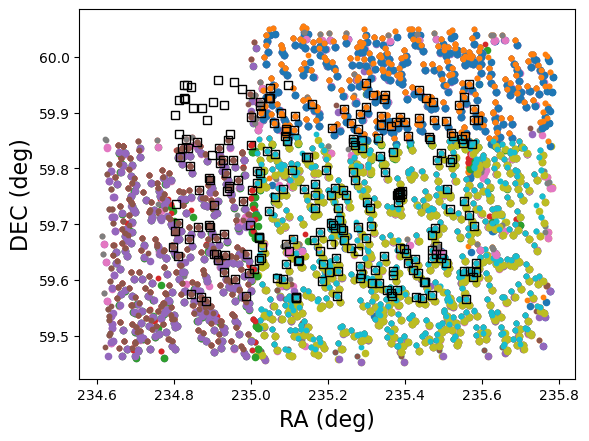

In [82]:
devpath = "/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/pointing002/"

catlist = glob.glob("WFC.r*.cat")
plt.figure()
for c in catlist:
    cbase = os.path.basename(c)
    c2 = os.path.join(devpath,cbase)
    compare_cats(c,c2)
    
    #break
panfile = c2.split('_')[0] + '_pan_tab.csv'
pantab1 = Table.read(panfile)
plt.plot(pantab1['RAJ2000'],pantab1['DEJ2000'],'ks',mfc='None',label="panstarrs")
#plt.legend()
plt.xlabel("RA (deg)", fontsize=16)
plt.ylabel("DEC (deg)", fontsize=16)

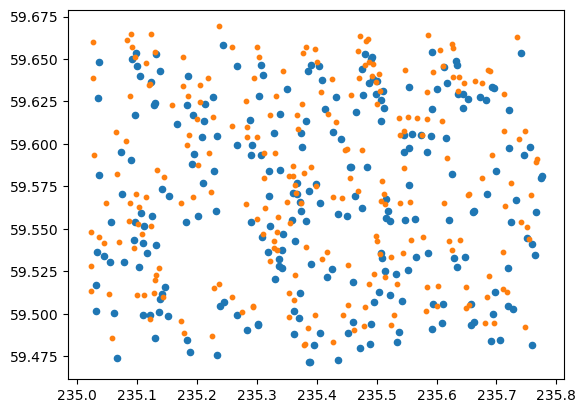

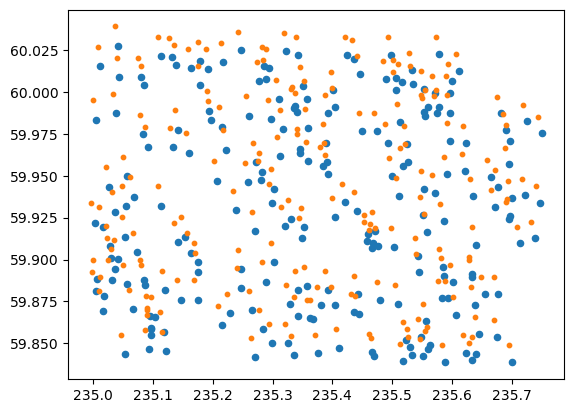

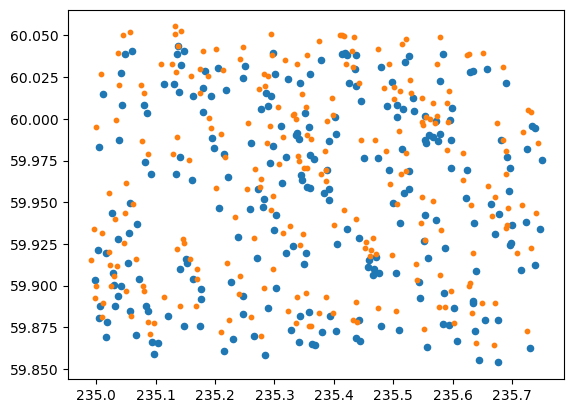

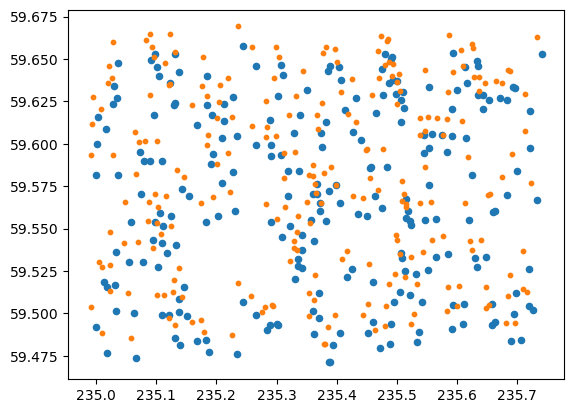

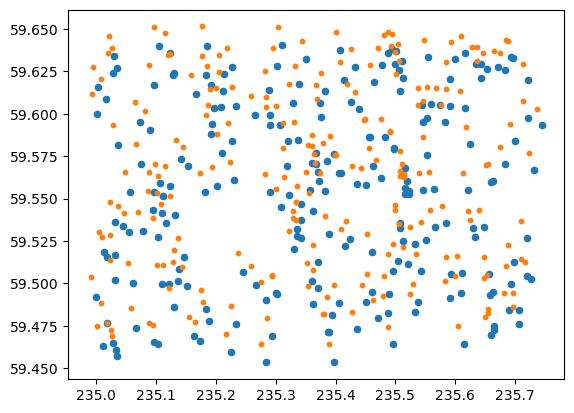

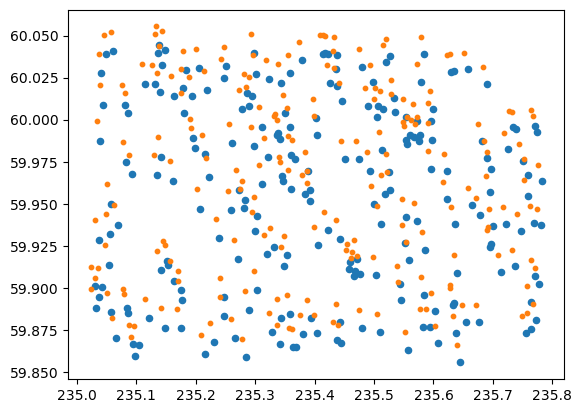

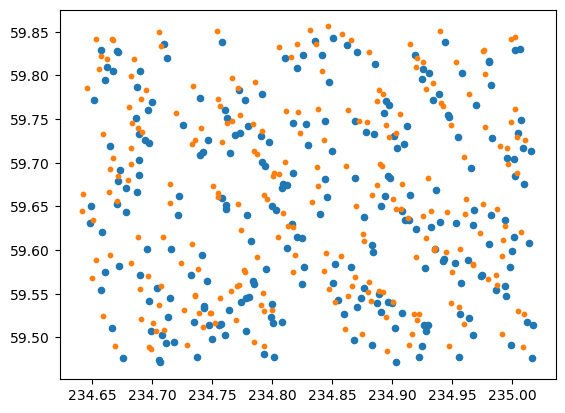

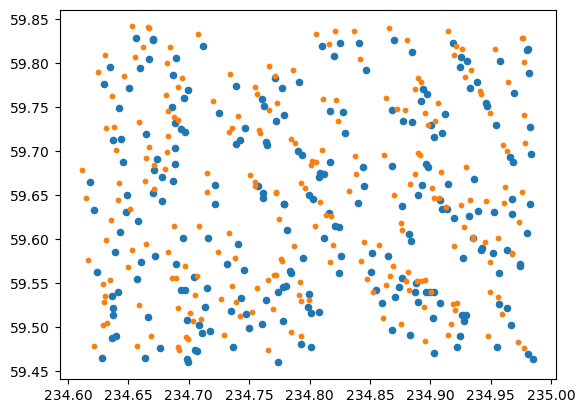

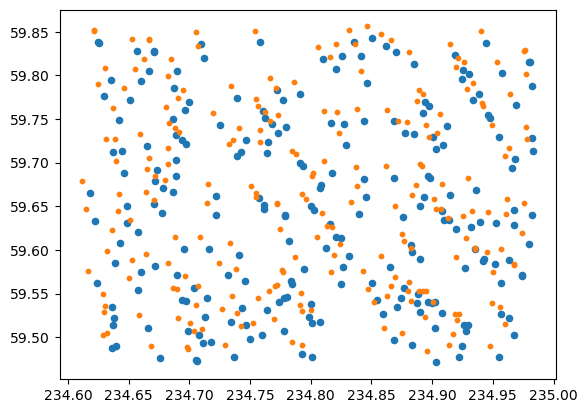

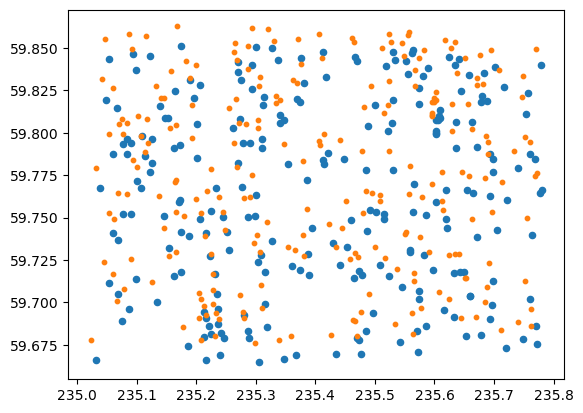

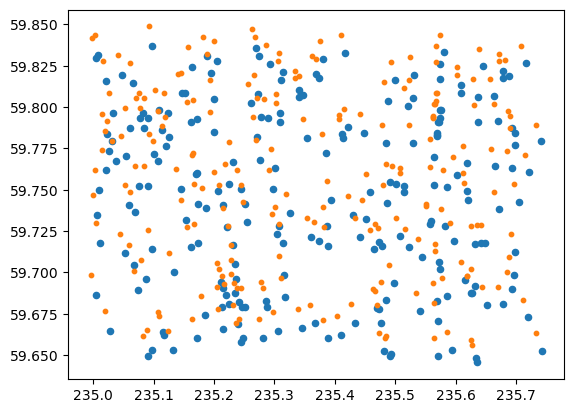

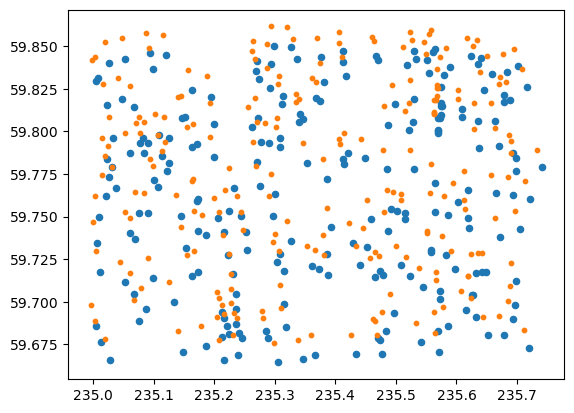

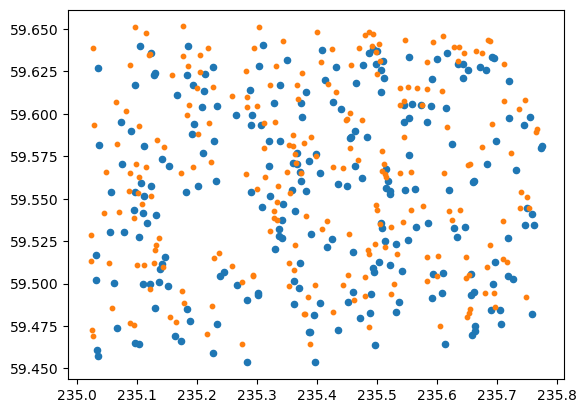

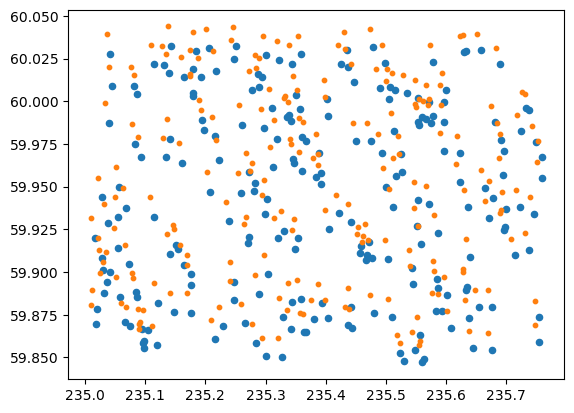

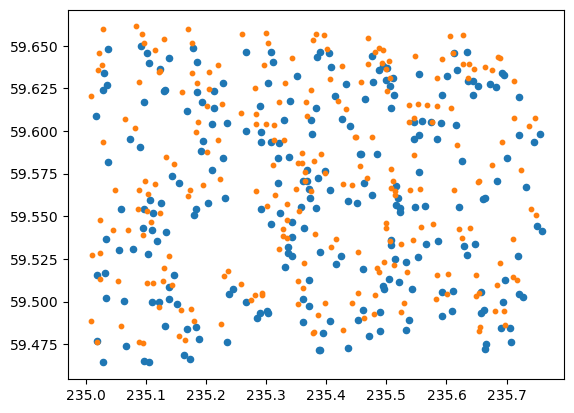

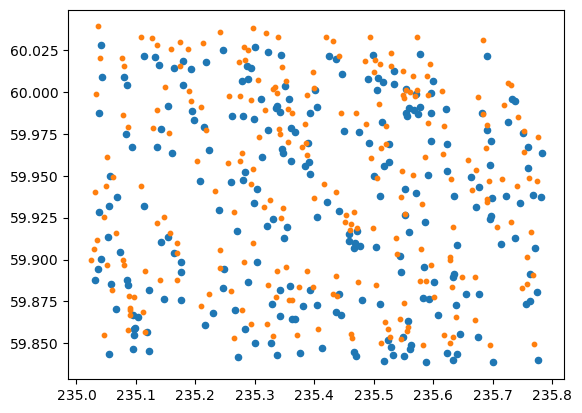

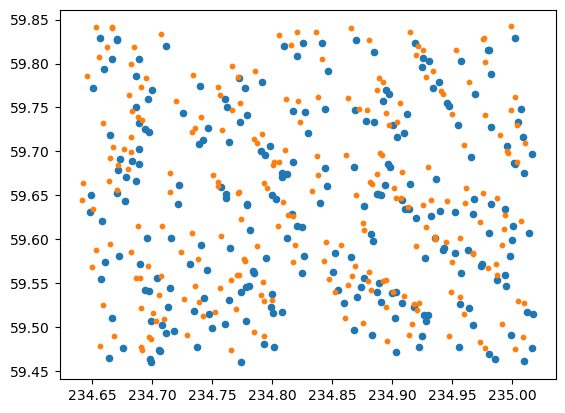

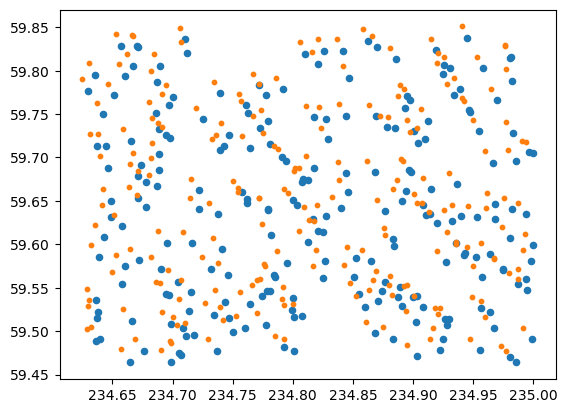

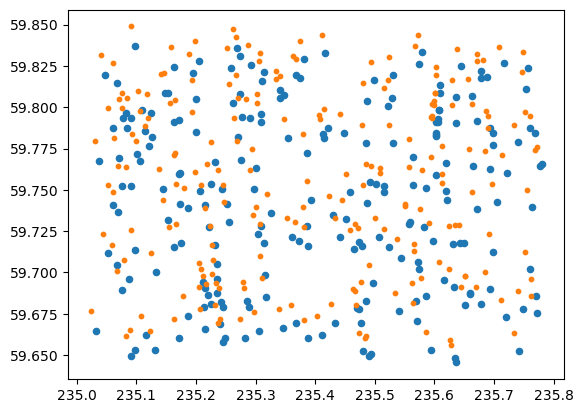

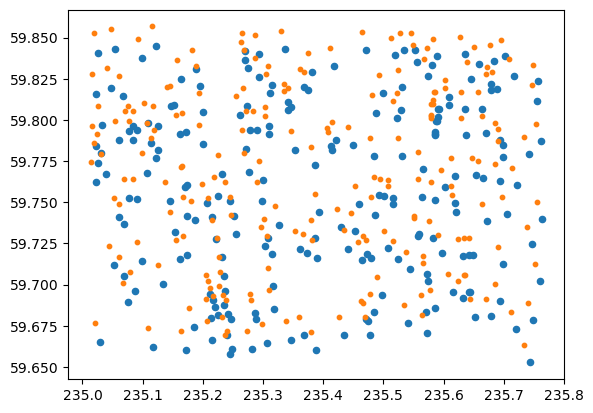

In [64]:
devpath = "/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/pointing002/"

catlist = glob.glob("WFC.r*.cat")
for c in catlist:
    cbase = os.path.basename(c)
    c2 = os.path.join(devpath,cbase)
    compare_cats(c,c2)
   

In [80]:
os.pardir

'..'

# Making a separate test directory to check coordinates

* check coords that you get in SE catalog when you have the *.head files in the directory vs. non header files

Text(0, 0.5, 'DEC (deg)')

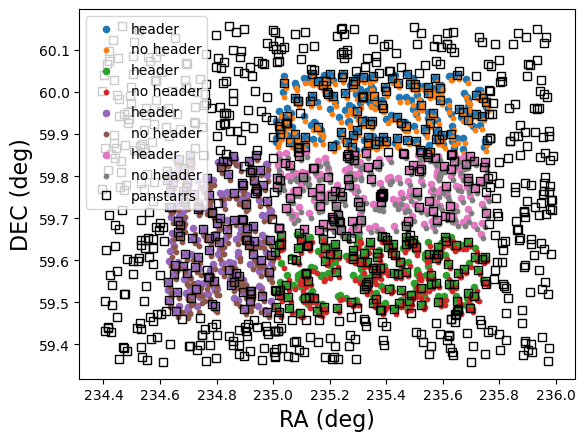

In [89]:

basepath = "/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/se_coord_panstarrs_match_test"
os.chdir(basepath)

# test directories
hdir = os.path.join(basepath,'pointing002_test_wheader/')
nohdir = os.path.join(basepath,'pointing002_test_noheader/')

catlist = glob.glob(hdir+"WFC.r*.cat")
plt.figure()
for c in catlist:
    cbase = os.path.basename(c)
    c2 = os.path.join(nohdir,cbase)
    compare_cats(c,c2,labels=['header','no header'])
    
    #break
panfile = c2.split('_')[0] + '_pan_tab.csv'
panfile = os.path.join(hdir,"WFC.r.2019-05-30T23:36:23.5_pan_tab.csv")
pantab1 = Table.read(panfile)
plt.plot(pantab1['RAJ2000'],pantab1['DEJ2000'],'ks',mfc='None',label="panstarrs")
plt.legend()
plt.xlabel("RA (deg)", fontsize=16)
plt.ylabel("DEC (deg)", fontsize=16)

# Problem with 2019 nelvy pointing 033

* getting no lines read in from some of r-band catalogs.
* copied them over to laptop

In [90]:
basedir = "/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/problems/pointing033/"


In [92]:
catlist

['/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/problems/pointing033/mWFC.r.2019-06-01T23:29:55.2_2PA.cat',
 '/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/problems/pointing033/mWFC.r.2019-06-01T23:29:55.2_4PA.cat',
 '/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/problems/pointing033/mWFC.r.2019-06-01T23:29:55.2_3PA.cat',
 '/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019nelvy-all/problems/pointing033/mWFC.r.2019-06-01T23:29:55.2_1PA.cat']

mWFC.r.2019-06-01T23:29:55.2_2PA.cat number of sources=216, keepflag=202
mWFC.r.2019-06-01T23:29:55.2_4PA.cat number of sources=238, keepflag=223
mWFC.r.2019-06-01T23:29:55.2_3PA.cat number of sources=186, keepflag=176
mWFC.r.2019-06-01T23:29:55.2_1PA.cat number of sources=218, keepflag=205


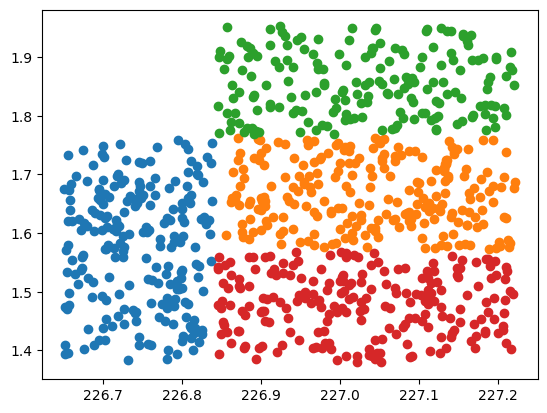

In [100]:
catlist = glob.glob(os.path.join(basedir,'*.cat'))
plt.figure()
for c in catlist:
    tab = fits.getdata(c,2)
    keepflag =  (tab['FLAGS'] <  1) #& (tab['CLASS_STAR'] > 0.85)
    print(f"{os.path.basename(c)} number of sources={len(tab)}, keepflag={np.sum(keepflag)}")
    
    plt.scatter(tab['ALPHA_J2000'],tab['DELTA_J2000'])

mWFC.r.2019-06-01T23:39:01.6_4PA.cat number of sources=191, keepflag=167
0
0
mWFC.r.2019-06-01T23:25:44.3_2PA.cat number of sources=270, keepflag=255
0
0
mWFC.r.2019-06-01T23:39:01.6_2PA.cat number of sources=181, keepflag=164
0
0
mWFC.r.2019-06-01T23:25:44.3_4PA.cat number of sources=266, keepflag=243
0
0
mWFC.r.2019-06-01T23:25:44.3_3PA.cat number of sources=230, keepflag=219
0
0
mWFC.r.2019-06-01T23:25:44.3_1PA.cat number of sources=252, keepflag=240
0
0
mWFC.r.2019-06-01T23:39:01.6_1PA.cat number of sources=169, keepflag=159
0
0
mWFC.r.2019-06-01T23:39:01.6_3PA.cat number of sources=137, keepflag=124
0
0
mWFC.r.2019-06-01T23:32:23.6_4PA.cat number of sources=197, keepflag=178
0
0
mWFC.r.2019-06-01T23:29:55.2_2PA.cat number of sources=216, keepflag=202
0
0
mWFC.r.2019-06-01T23:35:34.8_3PA.cat number of sources=118, keepflag=105
0
0
mWFC.r.2019-06-01T23:29:55.2_4PA.cat number of sources=238, keepflag=223
0
0
mWFC.r.2019-06-01T23:32:23.6_2PA.cat number of sources=190, keepflag=174
0
0

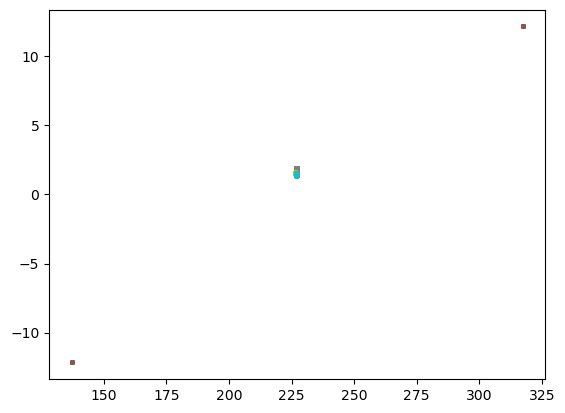

In [104]:
catlist = glob.glob(os.path.join(basedir,'*.cat'))
plt.figure()
for c in catlist:
    tab = fits.getdata(c,2)
    keepflag =  (tab['FLAGS'] <  1) #& (tab['CLASS_STAR'] > 0.85)
    print(f"{os.path.basename(c)} number of sources={len(tab)}, keepflag={np.sum(keepflag)}")
    print(f"{np.sum(tab['ALPHA_J2000'] < 200)}")
    print(f"{np.sum(tab['ALPHA_J2000'] > 250)}")
    plt.scatter(tab['ALPHA_J2000'],tab['DELTA_J2000'],s=5)

ended up removing the one problematic file, and then it was ok.

# QC on 2022 Data

0 1 mWFC.r.2022-05-01T21:45:52.9_1PA.cat
1 2 mWFC.r.2022-05-01T21:45:52.9_3PA.cat
2 3 mWFC.r.2022-05-01T21:45:52.9_4PA.cat
3 4 mWFC.r.2022-05-01T21:45:52.9_2PA.cat
0 1 mWFC.r.2022-05-01T21:49:53.6_1PA.cat
1 2 mWFC.r.2022-05-01T21:49:53.6_3PA.cat
2 3 mWFC.r.2022-05-01T21:49:53.6_2PA.cat
3 4 mWFC.r.2022-05-01T21:49:53.6_4PA.cat
0 1 mWFC.r.2022-05-01T21:41:52.5_1PA.cat
1 2 mWFC.r.2022-05-01T21:41:52.5_3PA.cat
2 3 mWFC.r.2022-05-01T21:41:52.5_2PA.cat
3 4 mWFC.r.2022-05-01T21:41:52.5_4PA.cat
0 1 mWFC.r.2022-05-01T21:47:53.8_3PA.cat
1 2 mWFC.r.2022-05-01T21:47:53.8_1PA.cat
2 3 mWFC.r.2022-05-01T21:47:53.8_4PA.cat
3 4 mWFC.r.2022-05-01T21:47:53.8_2PA.cat
0 1 mWFC.r.2022-05-01T21:43:51.8_4PA.cat
1 2 mWFC.r.2022-05-01T21:43:51.8_2PA.cat
2 3 mWFC.r.2022-05-01T21:43:51.8_3PA.cat
3 4 mWFC.r.2022-05-01T21:43:51.8_1PA.cat


<Figure size 640x480 with 0 Axes>

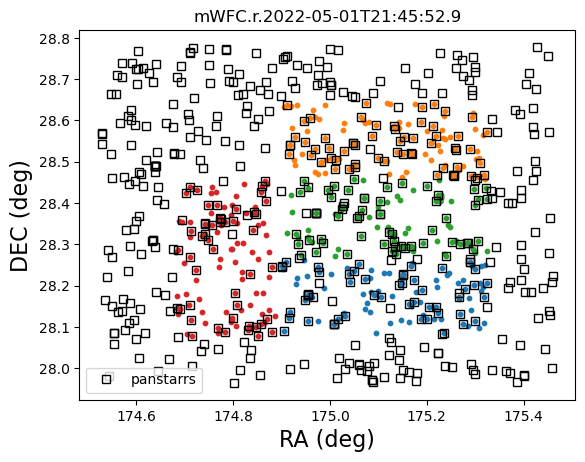

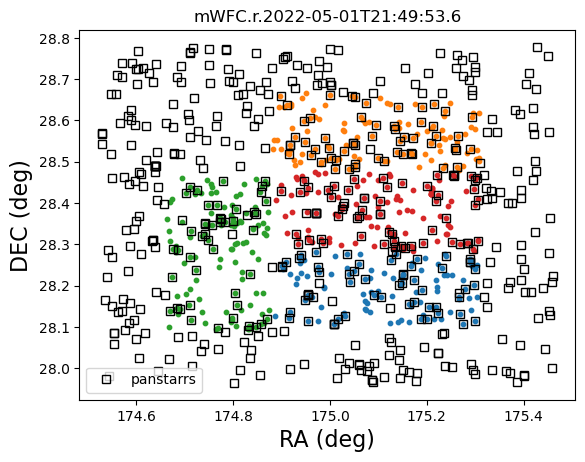

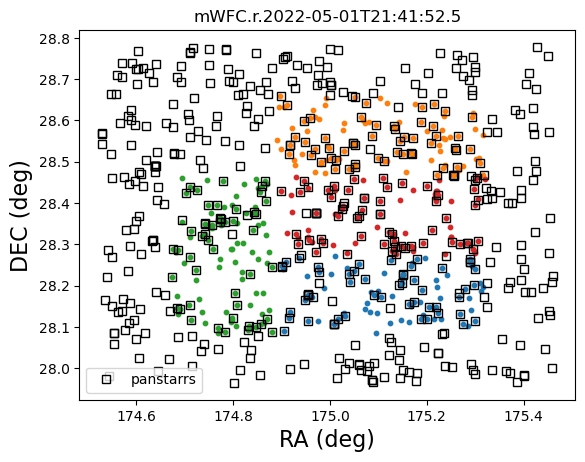

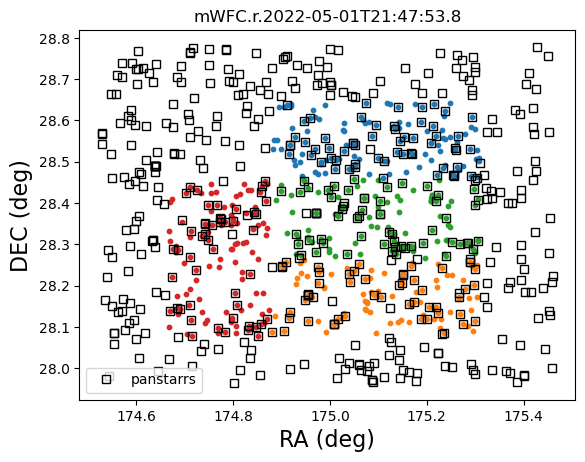

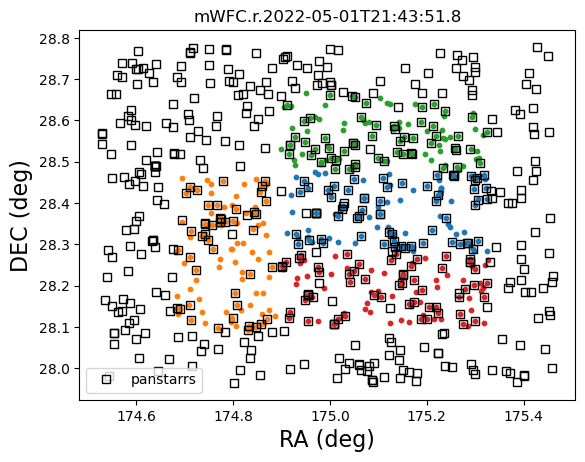

In [130]:
mycolors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_panstarrs():
    # read in panstarrs
    panfile = os.path.join(basedir,'mWFC.r._pan_tab.csv')
    #panfile = os.path.join(hdir,"WFC.r.2019-05-30T23:36:23.5_pan_tab.csv")
    pantab1 = Table.read(panfile)
    plt.plot(pantab1['RAJ2000'],pantab1['DEJ2000'],'ks',mfc='None',label="panstarrs")
    plt.legend()
    plt.xlabel("RA (deg)", fontsize=16)
    plt.ylabel("DEC (deg)", fontsize=16)
    
    
basedir = "/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2022MayINT-allfiles-v2/target_0/"
catlist = glob.glob(os.path.join(basedir,'mWFC*.cat'))
catlist = [os.path.basename(imname) for imname in catlist]
allfilerootlist = [t.split('_')[0] for t in catlist]
#print(allfilerootlist)
filerootlist = list(set(allfilerootlist))
#print(filerootlist)

plt.figure()

for i in range(len(filerootlist)):
    image_cat_list = [m for m in catlist if filerootlist[i] in m]
    plt.figure()
    nplot=1
    for j,c in enumerate(image_cat_list):
        print(j,nplot,c)
        tab = fits.getdata(os.path.join(basedir,c),2)
        keepflag =  (tab['FLAGS'] <  1) #& (tab['CLASS_STAR'] > 0.85)
        #print(f"{os.path.basename(c)} number of sources={len(tab)}, keepflag={np.sum(keepflag)}")
        
        plt.scatter(tab['ALPHA_J2000'],tab['DELTA_J2000'],s=10,c=mycolors[nplot-1])
        nplot += 1
    plot_panstarrs()
    plt.title(os.path.basename(filerootlist[i]))
        
    


## Problem with target_4

0 1 mWFC.r.2022-05-02T01:19:49.5_2PA.cat
1 2 mWFC.r.2022-05-02T01:19:49.5_4PA.cat
2 3 mWFC.r.2022-05-02T01:19:49.5_1PA.cat
3 4 mWFC.r.2022-05-02T01:19:49.5_3PA.cat
0 1 mWFC.r.2022-05-02T01:17:48.4_1PA.cat
1 2 mWFC.r.2022-05-02T01:17:48.4_3PA.cat
2 3 mWFC.r.2022-05-02T01:17:48.4_2PA.cat
3 4 mWFC.r.2022-05-02T01:17:48.4_4PA.cat
0 1 mWFC.r.2022-05-05T00:34:14.7_2PA.cat
1 2 mWFC.r.2022-05-05T00:34:14.7_4PA.cat
2 3 mWFC.r.2022-05-05T00:34:14.7_3PA.cat
3 4 mWFC.r.2022-05-05T00:34:14.7_1PA.cat
0 1 mWFC.r.2022-05-05T00:40:14.5_2PA.cat
1 2 mWFC.r.2022-05-05T00:40:14.5_4PA.cat
2 3 mWFC.r.2022-05-05T00:40:14.5_1PA.cat
3 4 mWFC.r.2022-05-05T00:40:14.5_3PA.cat
0 1 mWFC.r.2022-05-05T00:38:14.3_2PA.cat
1 2 mWFC.r.2022-05-05T00:38:14.3_4PA.cat
2 3 mWFC.r.2022-05-05T00:38:14.3_1PA.cat
3 4 mWFC.r.2022-05-05T00:38:14.3_3PA.cat
0 1 mWFC.r.2022-05-02T01:13:48.9_3PA.cat
1 2 mWFC.r.2022-05-02T01:13:48.9_1PA.cat
2 3 mWFC.r.2022-05-02T01:13:48.9_2PA.cat
3 4 mWFC.r.2022-05-02T01:13:48.9_4PA.cat
0 1 mWFC.r.2022-

<Figure size 640x480 with 0 Axes>

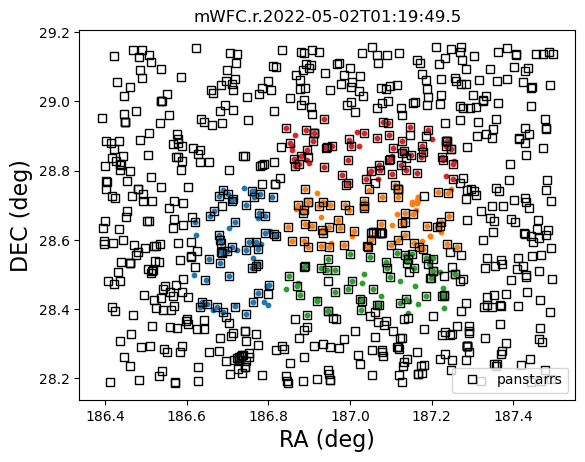

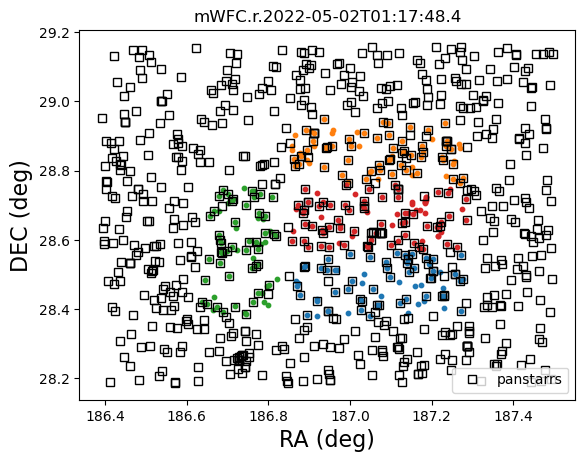

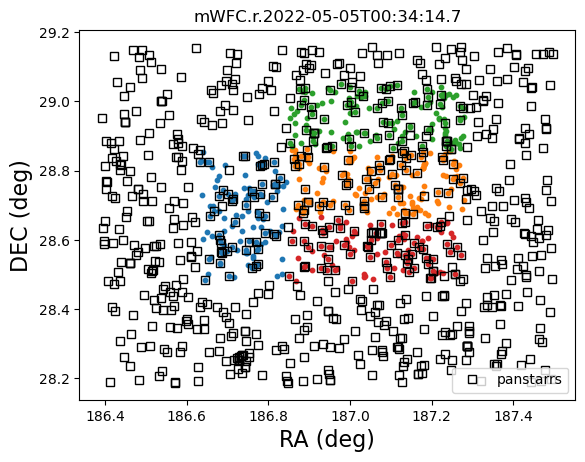

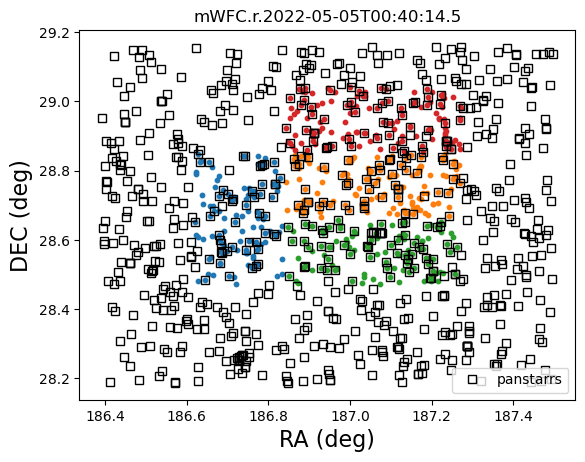

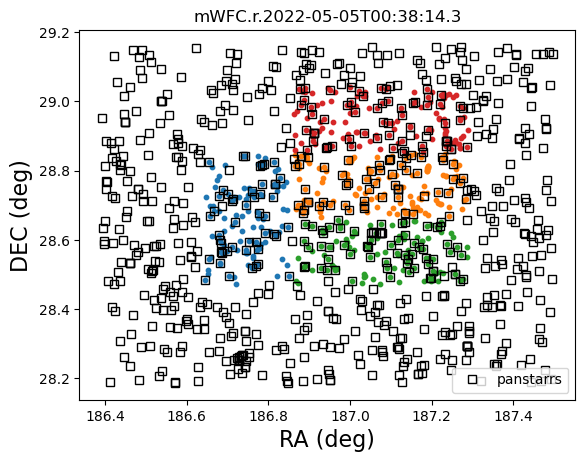

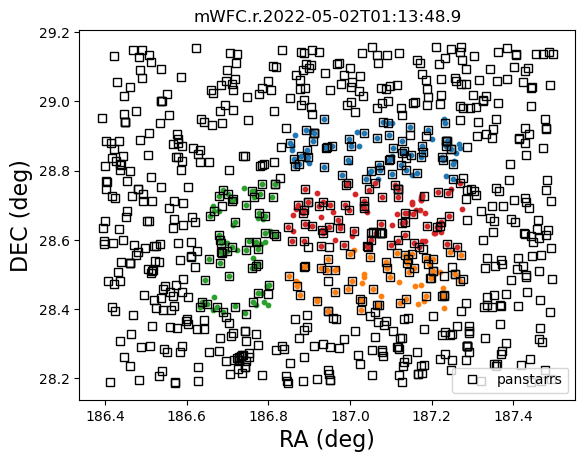

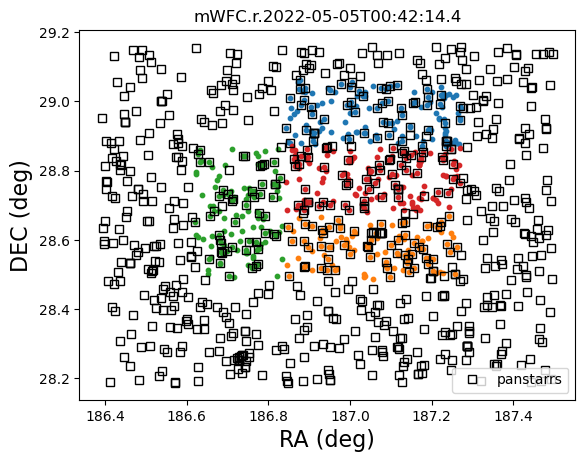

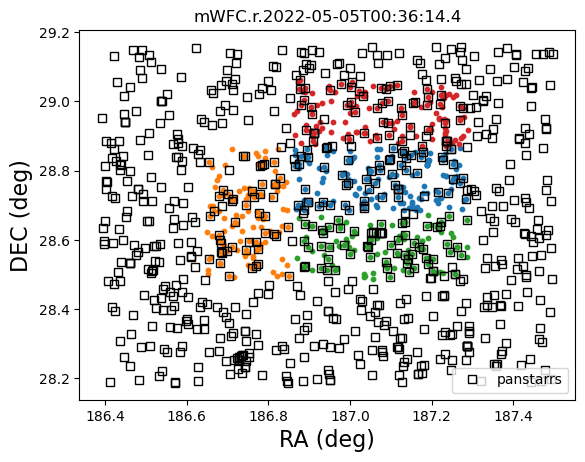

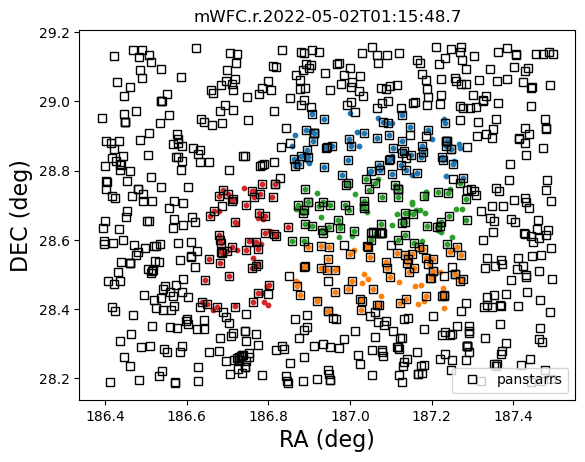

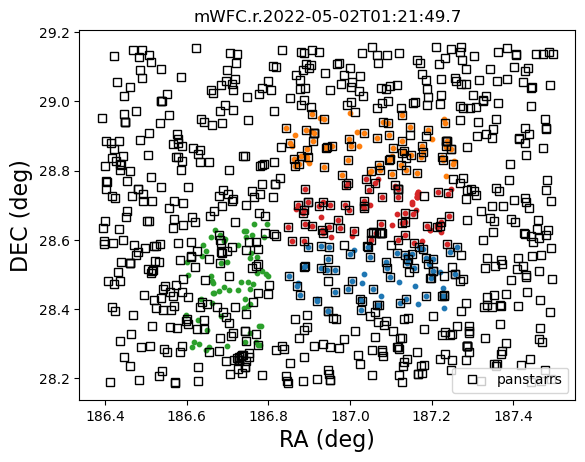

In [133]:
mycolors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_panstarrs():
    # read in panstarrs
    panfile = os.path.join(basedir,'mWFC.r._pan_tab.csv')
    #panfile = os.path.join(hdir,"WFC.r.2019-05-30T23:36:23.5_pan_tab.csv")
    pantab1 = Table.read(panfile)
    plt.plot(pantab1['RAJ2000'],pantab1['DEJ2000'],'ks',mfc='None',label="panstarrs")
    plt.legend()
    plt.xlabel("RA (deg)", fontsize=16)
    plt.ylabel("DEC (deg)", fontsize=16)
    
    
basedir = "/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2022MayINT-allfiles-v2/problems/target_4/"
catlist = glob.glob(os.path.join(basedir,'mWFC.r*.cat'))
catlist = [os.path.basename(imname) for imname in catlist]
allfilerootlist = [t.split('_')[0] for t in catlist]
#print(allfilerootlist)
filerootlist = list(set(allfilerootlist))
#print(filerootlist)

plt.figure()

for i in range(len(filerootlist)):
    image_cat_list = [m for m in catlist if filerootlist[i] in m]
    plt.figure()
    nplot=1
    for j,c in enumerate(image_cat_list):
        print(j,nplot,c)
        tab = fits.getdata(os.path.join(basedir,c),2)
        keepflag =  (tab['FLAGS'] <  1) #& (tab['CLASS_STAR'] > 0.85)
        #print(f"{os.path.basename(c)} number of sources={len(tab)}, keepflag={np.sum(keepflag)}")
        
        plt.scatter(tab['ALPHA_J2000'],tab['DELTA_J2000'],s=10,c=mycolors[nplot-1])
        nplot += 1
    plot_panstarrs()
    plt.title(os.path.basename(filerootlist[i]))
        
    


/var/folders/d_/xbzntjjj2rz0d1tfc4s267ww0000gq/T/ipykernel_92025/1446910413.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<Figure size 640x480 with 0 Axes>

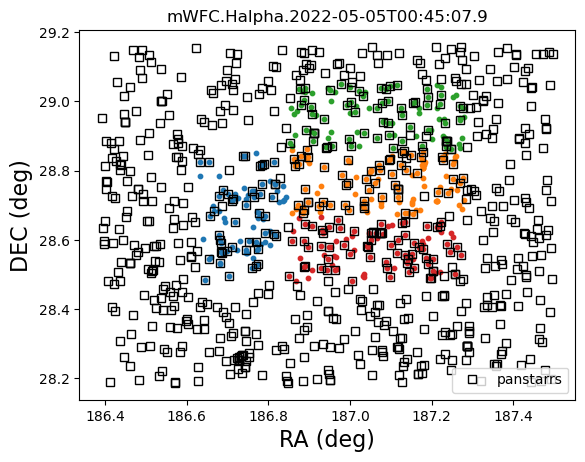

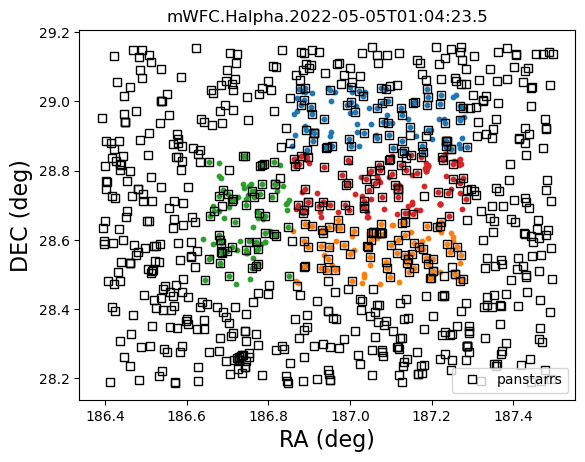

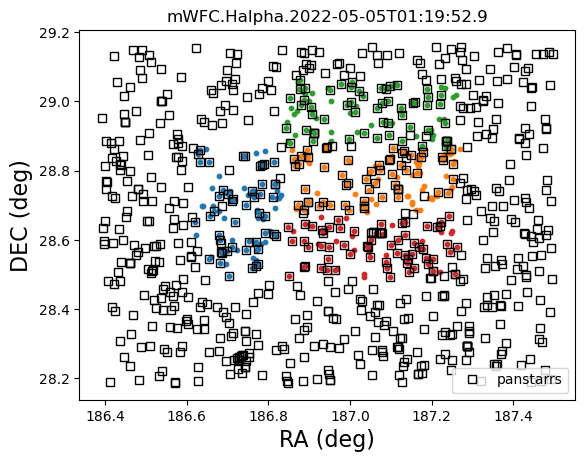

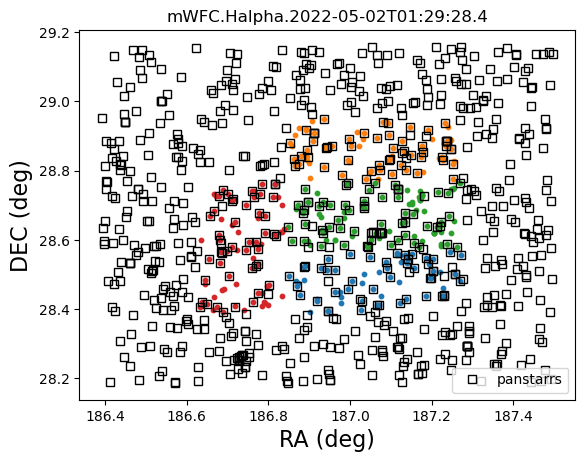

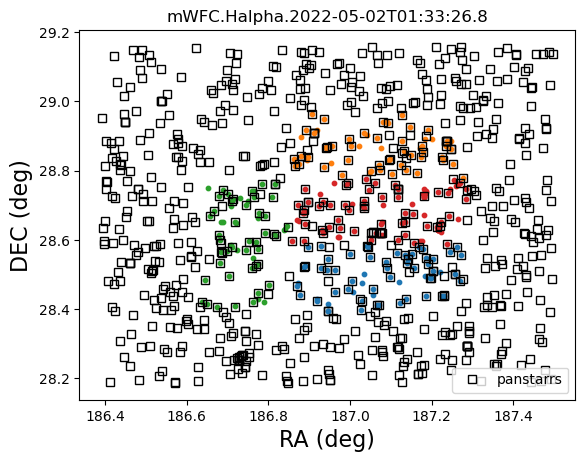

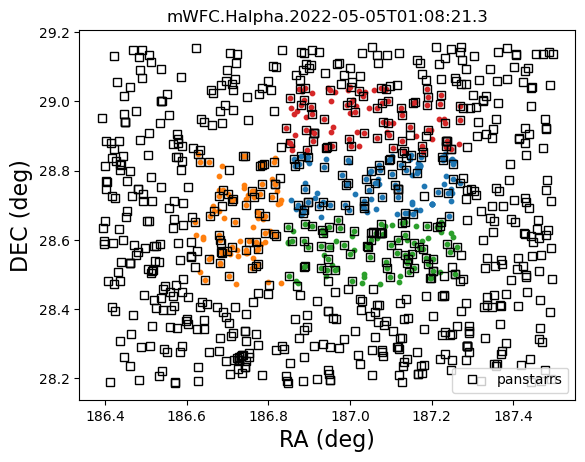

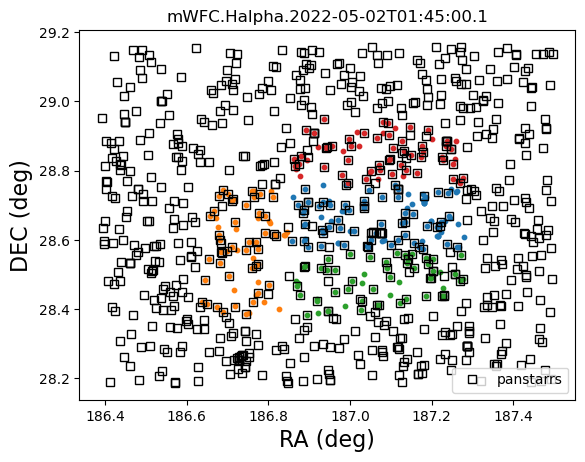

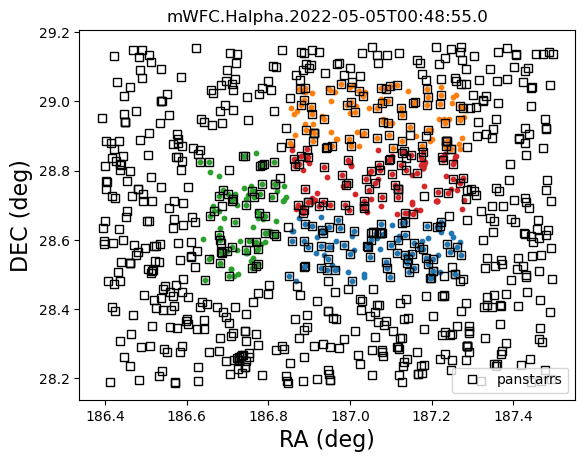

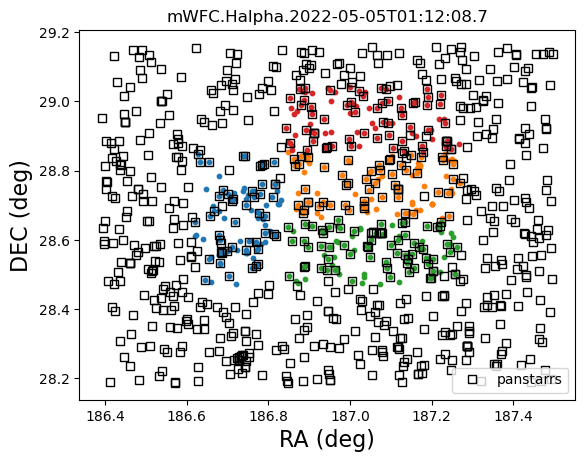

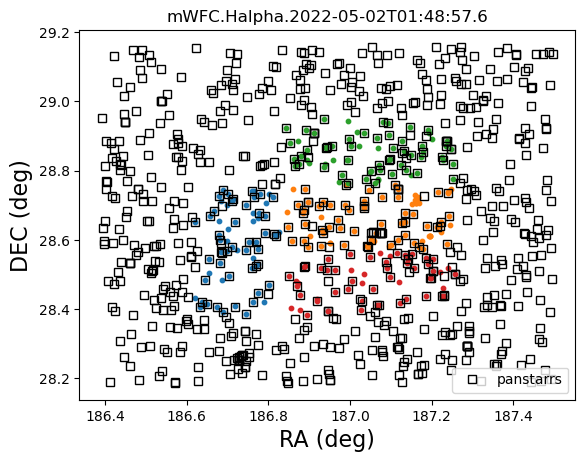

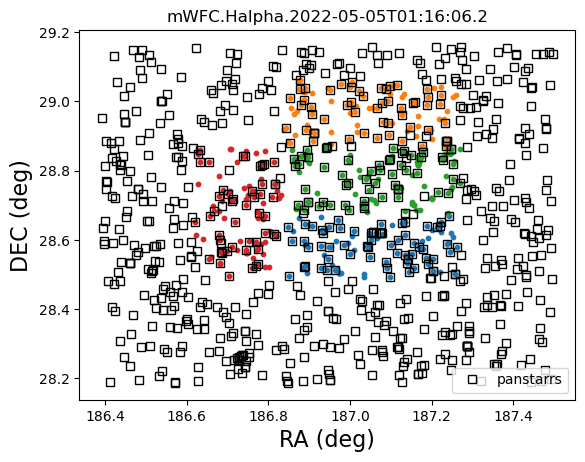

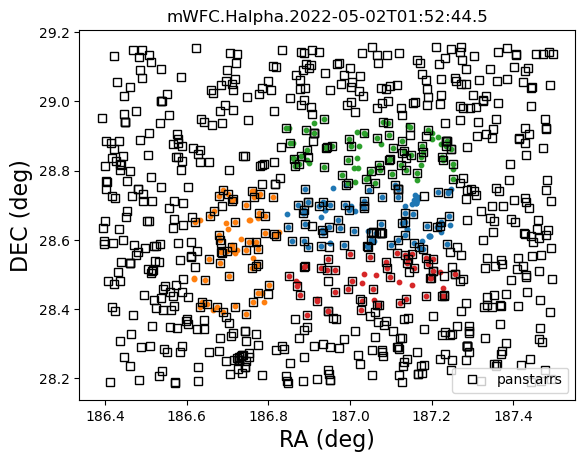

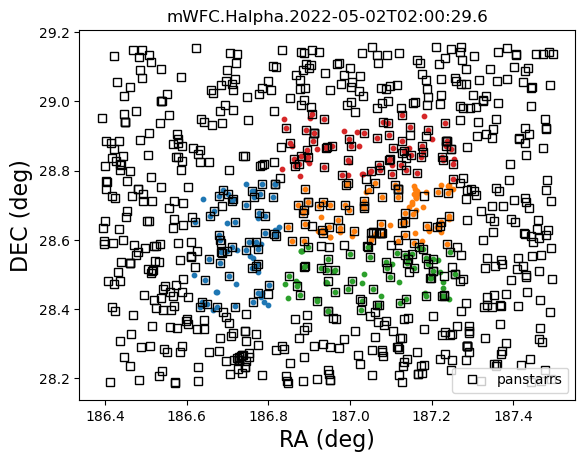

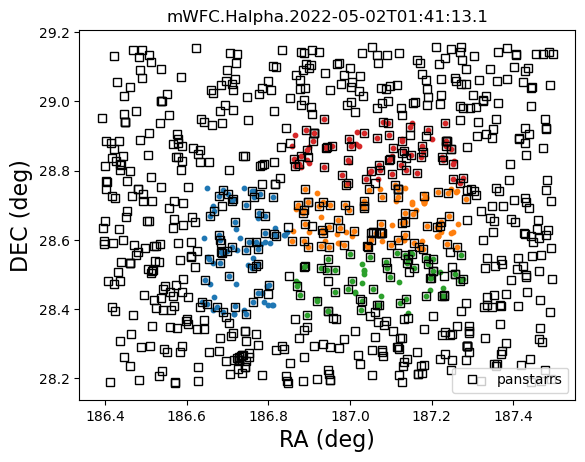

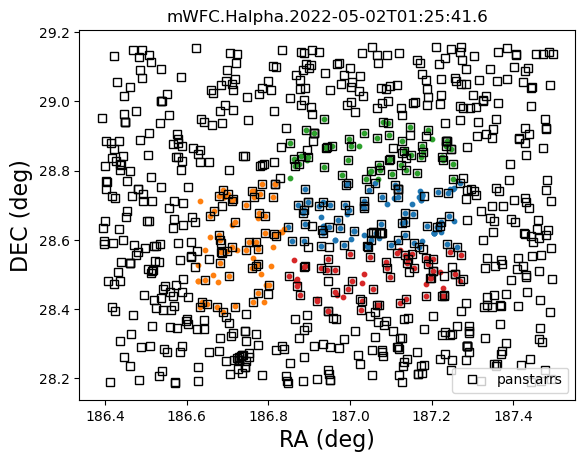

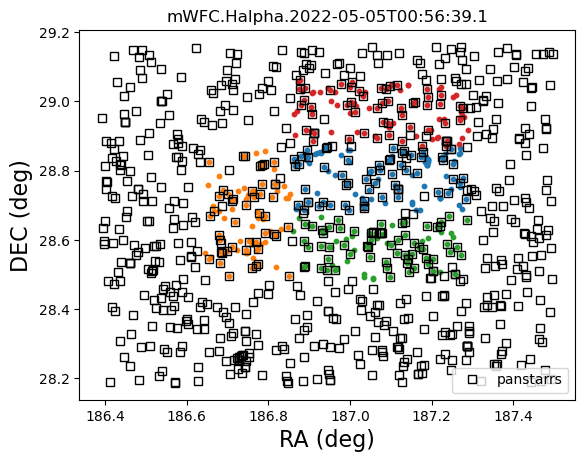

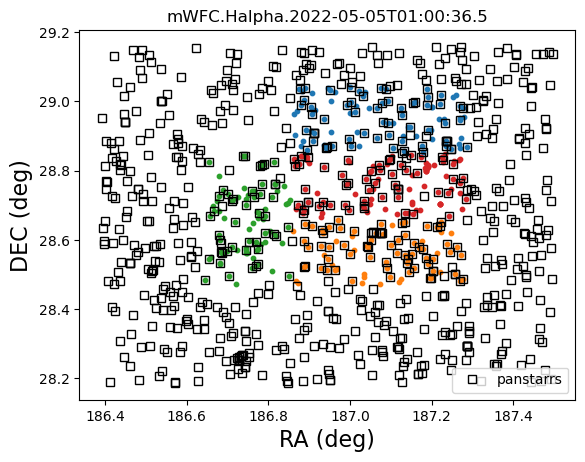

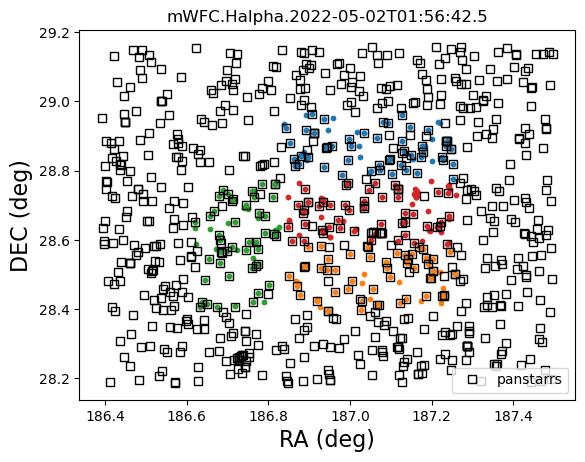

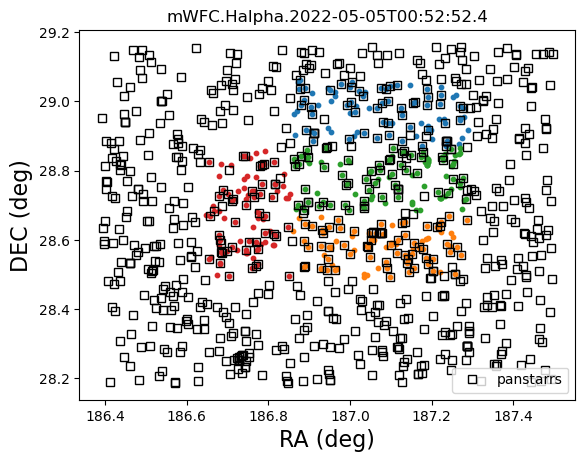

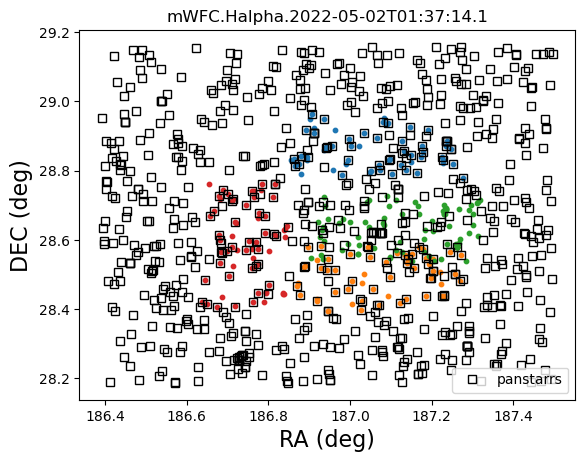

In [136]:
mycolors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_panstarrs():
    # read in panstarrs
    panfile = os.path.join(basedir,'mWFC.r._pan_tab.csv')
    #panfile = os.path.join(hdir,"WFC.r.2019-05-30T23:36:23.5_pan_tab.csv")
    pantab1 = Table.read(panfile)
    plt.plot(pantab1['RAJ2000'],pantab1['DEJ2000'],'ks',mfc='None',label="panstarrs")
    plt.legend()
    plt.xlabel("RA (deg)", fontsize=16)
    plt.ylabel("DEC (deg)", fontsize=16)
    
    
basedir = "/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2022MayINT-allfiles-v2/problems/target_4/"
catlist = glob.glob(os.path.join(basedir,'mWFC.H*.cat'))
catlist = [os.path.basename(imname) for imname in catlist]
allfilerootlist = [t.split('_')[0] for t in catlist]
#print(allfilerootlist)
filerootlist = list(set(allfilerootlist))
#print(filerootlist)
plt.close('all')
plt.figure()

for i in range(len(filerootlist)):
    image_cat_list = [m for m in catlist if filerootlist[i] in m]
    plt.figure()
    nplot=1
    for j,c in enumerate(image_cat_list):
        #print(j,nplot,c)
        tab = fits.getdata(os.path.join(basedir,c),2)
        keepflag =  (tab['FLAGS'] <  1) #& (tab['CLASS_STAR'] > 0.85)
        #print(f"{os.path.basename(c)} number of sources={len(tab)}, keepflag={np.sum(keepflag)}")
        
        plt.scatter(tab['ALPHA_J2000'],tab['DELTA_J2000'],s=10,c=mycolors[nplot-1])
        nplot += 1
    plot_panstarrs()
    plt.title(os.path.basename(filerootlist[i]))
        
    


## Problems with target_16

0 1 mWFC.r.2022-05-04T04:42:59.8_1PA.cat
1 2 mWFC.r.2022-05-04T04:42:59.8_3PA.cat
2 3 mWFC.r.2022-05-04T04:42:59.8_2PA.cat
3 4 mWFC.r.2022-05-04T04:42:59.8_4PA.cat
0 1 mWFC.r.2022-05-03T05:03:43.1_3PA.cat
1 2 mWFC.r.2022-05-03T05:03:43.1_1PA.cat
2 3 mWFC.r.2022-05-03T05:03:43.1_2PA.cat
3 4 mWFC.r.2022-05-03T05:03:43.1_4PA.cat
0 1 mWFC.r.2022-05-04T04:40:59.6_4PA.cat
1 2 mWFC.r.2022-05-04T04:40:59.6_2PA.cat
2 3 mWFC.r.2022-05-04T04:40:59.6_1PA.cat
3 4 mWFC.r.2022-05-04T04:40:59.6_3PA.cat
0 1 mWFC.r.2022-05-04T04:45:00.6_1PA.cat
1 2 mWFC.r.2022-05-04T04:45:00.6_3PA.cat
2 3 mWFC.r.2022-05-04T04:45:00.6_2PA.cat
3 4 mWFC.r.2022-05-04T04:45:00.6_4PA.cat
0 1 mWFC.r.2022-05-04T04:47:01.7_3PA.cat
1 2 mWFC.r.2022-05-04T04:47:01.7_1PA.cat
2 3 mWFC.r.2022-05-04T04:47:01.7_2PA.cat
3 4 mWFC.r.2022-05-04T04:47:01.7_4PA.cat
0 1 mWFC.r.2022-05-04T04:49:02.7_4PA.cat
1 2 mWFC.r.2022-05-04T04:49:02.7_2PA.cat
2 3 mWFC.r.2022-05-04T04:49:02.7_1PA.cat
3 4 mWFC.r.2022-05-04T04:49:02.7_3PA.cat
0 1 mWFC.r.2022-

<Figure size 640x480 with 0 Axes>

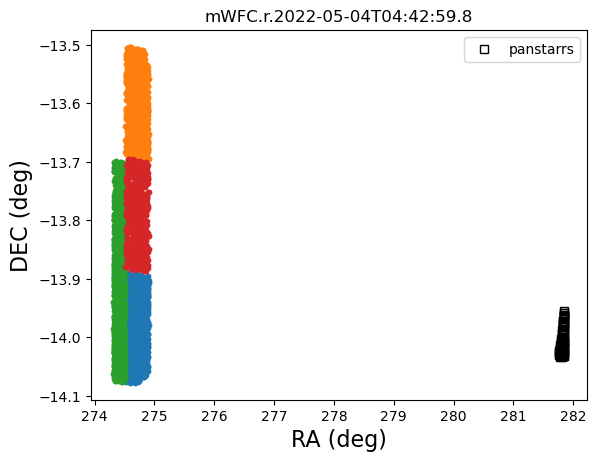

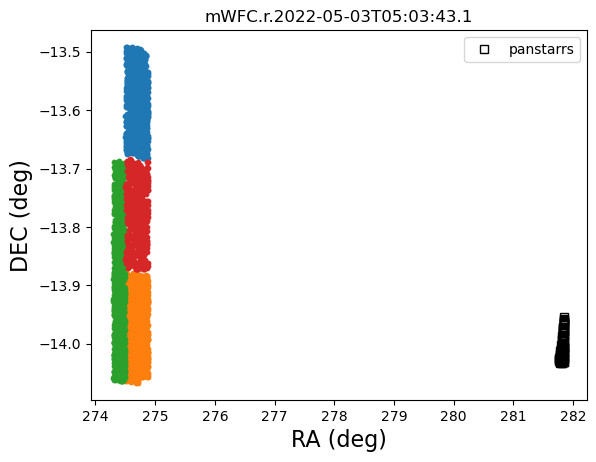

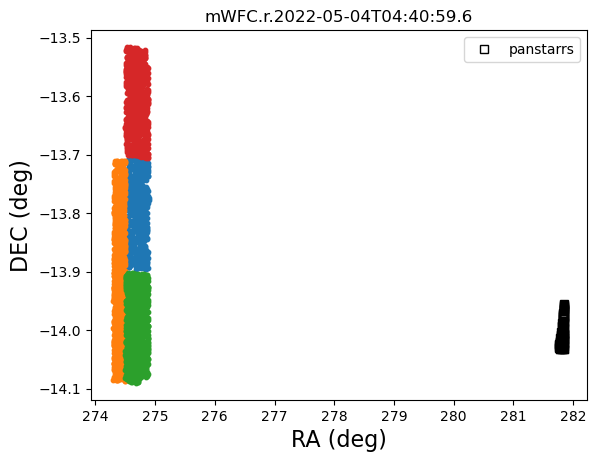

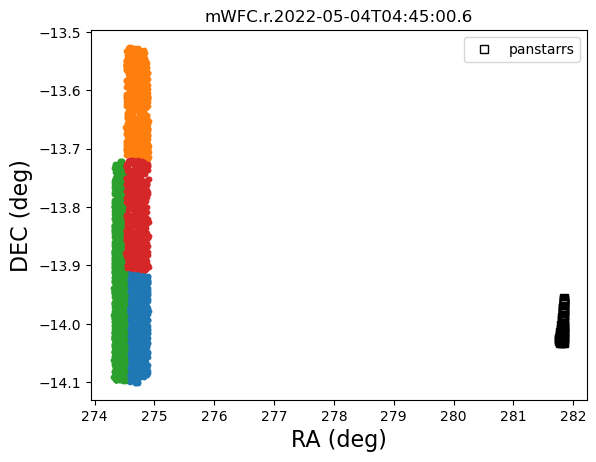

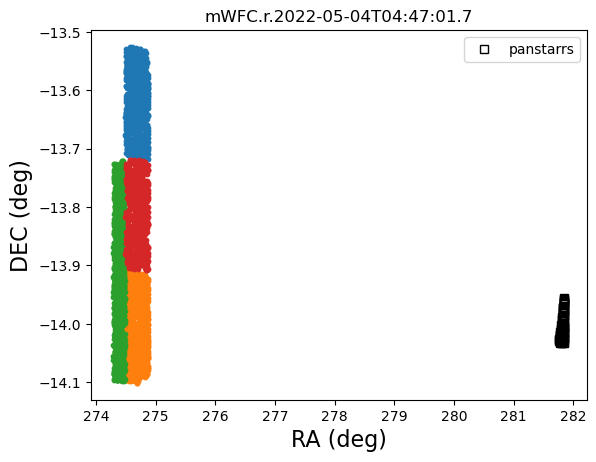

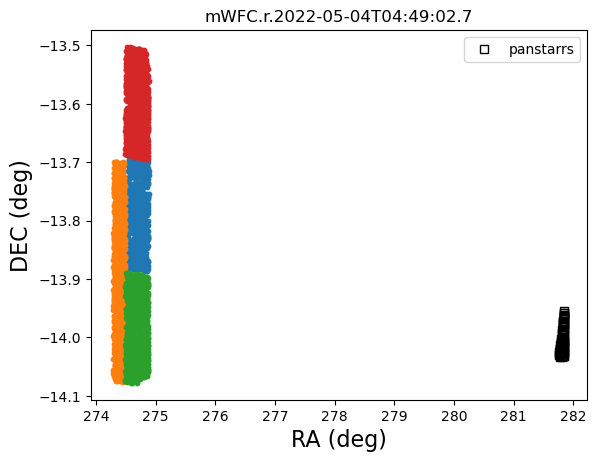

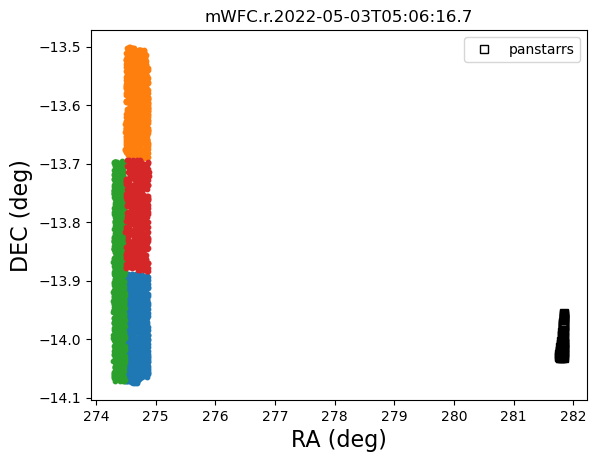

In [137]:
mycolors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_panstarrs():
    # read in panstarrs
    panfile = os.path.join(basedir,'mWFC.r._pan_tab.csv')
    #panfile = os.path.join(hdir,"WFC.r.2019-05-30T23:36:23.5_pan_tab.csv")
    pantab1 = Table.read(panfile)
    plt.plot(pantab1['RAJ2000'],pantab1['DEJ2000'],'ks',mfc='None',label="panstarrs")
    plt.legend()
    plt.xlabel("RA (deg)", fontsize=16)
    plt.ylabel("DEC (deg)", fontsize=16)
    
    
basedir = "/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2022MayINT-allfiles-v2/problems/target_16/"
catlist = glob.glob(os.path.join(basedir,'mWFC.r*.cat'))
catlist = [os.path.basename(imname) for imname in catlist]
allfilerootlist = [t.split('_')[0] for t in catlist]
#print(allfilerootlist)
filerootlist = list(set(allfilerootlist))
#print(filerootlist)

plt.figure()

for i in range(len(filerootlist)):
    image_cat_list = [m for m in catlist if filerootlist[i] in m]
    plt.figure()
    nplot=1
    for j,c in enumerate(image_cat_list):
        print(j,nplot,c)
        tab = fits.getdata(os.path.join(basedir,c),2)
        keepflag =  (tab['FLAGS'] <  1) #& (tab['CLASS_STAR'] > 0.85)
        #print(f"{os.path.basename(c)} number of sources={len(tab)}, keepflag={np.sum(keepflag)}")
        
        plt.scatter(tab['ALPHA_J2000'],tab['DELTA_J2000'],s=10,c=mycolors[nplot-1])
        nplot += 1
    plot_panstarrs()
    plt.title(os.path.basename(filerootlist[i]))
        
    


0 1 mWFC.Halpha.2022-05-03T05:09:19.6_2PA.cat
1 2 mWFC.Halpha.2022-05-03T05:09:19.6_4PA.cat
2 3 mWFC.Halpha.2022-05-03T05:09:19.6_1PA.cat
3 4 mWFC.Halpha.2022-05-03T05:09:19.6_3PA.cat
0 1 mWFC.Halpha.2022-05-04T04:27:39.7_1PA.cat
1 2 mWFC.Halpha.2022-05-04T04:27:39.7_3PA.cat
2 3 mWFC.Halpha.2022-05-04T04:27:39.7_4PA.cat
3 4 mWFC.Halpha.2022-05-04T04:27:39.7_2PA.cat
0 1 mWFC.Halpha.2022-05-04T04:19:40.4_3PA.cat
1 2 mWFC.Halpha.2022-05-04T04:19:40.4_1PA.cat
2 3 mWFC.Halpha.2022-05-04T04:19:40.4_4PA.cat
3 4 mWFC.Halpha.2022-05-04T04:19:40.4_2PA.cat
0 1 mWFC.Halpha.2022-05-04T04:35:41.6_3PA.cat
1 2 mWFC.Halpha.2022-05-04T04:35:41.6_1PA.cat
2 3 mWFC.Halpha.2022-05-04T04:35:41.6_2PA.cat
3 4 mWFC.Halpha.2022-05-04T04:35:41.6_4PA.cat
0 1 mWFC.Halpha.2022-05-04T04:31:41.0_4PA.cat
1 2 mWFC.Halpha.2022-05-04T04:31:41.0_2PA.cat
2 3 mWFC.Halpha.2022-05-04T04:31:41.0_3PA.cat
3 4 mWFC.Halpha.2022-05-04T04:31:41.0_1PA.cat
0 1 mWFC.Halpha.2022-05-04T04:23:39.5_1PA.cat
1 2 mWFC.Halpha.2022-05-04T04:23:3

<Figure size 640x480 with 0 Axes>

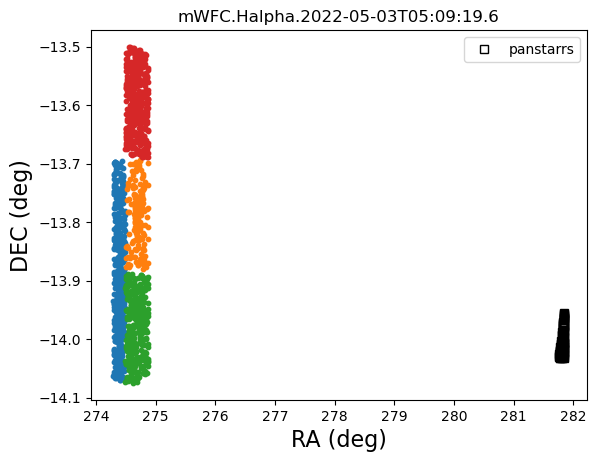

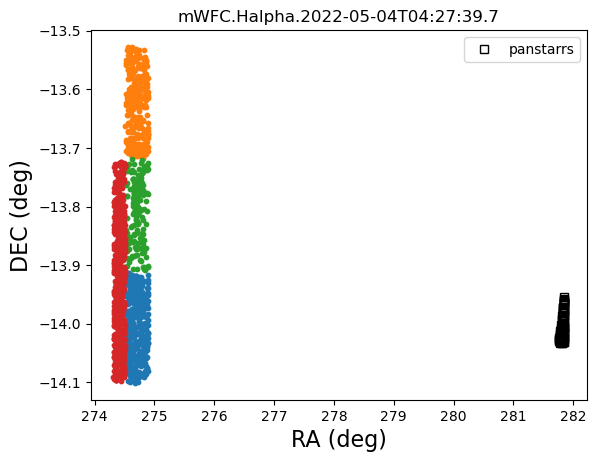

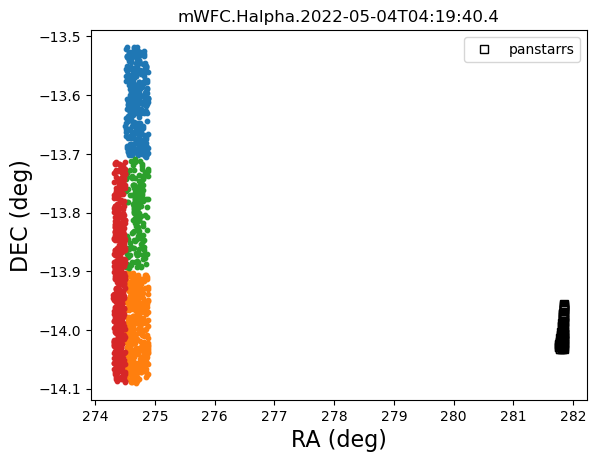

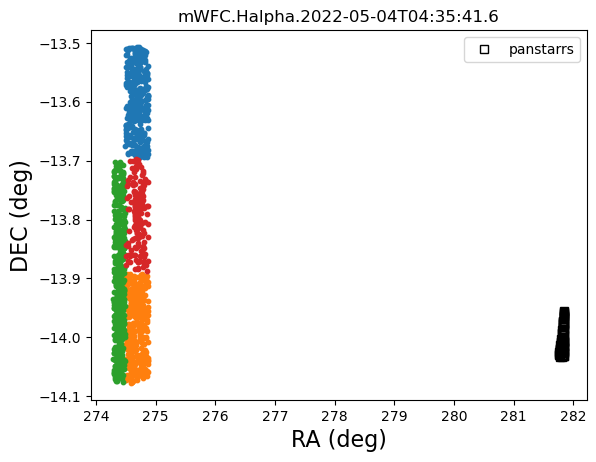

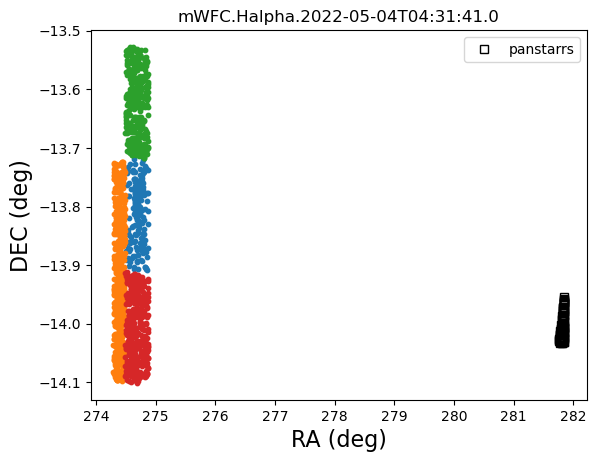

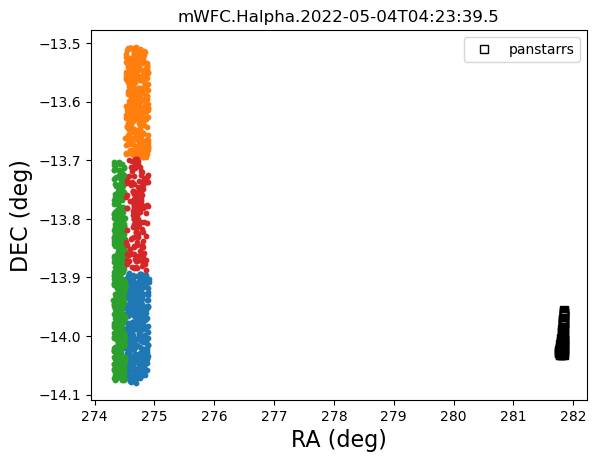

In [138]:
mycolors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_panstarrs():
    # read in panstarrs
    panfile = os.path.join(basedir,'mWFC.r._pan_tab.csv')
    #panfile = os.path.join(hdir,"WFC.r.2019-05-30T23:36:23.5_pan_tab.csv")
    pantab1 = Table.read(panfile)
    plt.plot(pantab1['RAJ2000'],pantab1['DEJ2000'],'ks',mfc='None',label="panstarrs")
    plt.legend()
    plt.xlabel("RA (deg)", fontsize=16)
    plt.ylabel("DEC (deg)", fontsize=16)
    
    
basedir = "/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2022MayINT-allfiles-v2/problems/target_16/"
catlist = glob.glob(os.path.join(basedir,'mWFC.H*.cat'))
catlist = [os.path.basename(imname) for imname in catlist]
allfilerootlist = [t.split('_')[0] for t in catlist]
#print(allfilerootlist)
filerootlist = list(set(allfilerootlist))
#print(filerootlist)

plt.figure()

for i in range(len(filerootlist)):
    image_cat_list = [m for m in catlist if filerootlist[i] in m]
    plt.figure()
    nplot=1
    for j,c in enumerate(image_cat_list):
        print(j,nplot,c)
        tab = fits.getdata(os.path.join(basedir,c),2)
        keepflag =  (tab['FLAGS'] <  1) #& (tab['CLASS_STAR'] > 0.85)
        #print(f"{os.path.basename(c)} number of sources={len(tab)}, keepflag={np.sum(keepflag)}")
        
        plt.scatter(tab['ALPHA_J2000'],tab['DELTA_J2000'],s=10,c=mycolors[nplot-1])
        nplot += 1
    plot_panstarrs()
    plt.title(os.path.basename(filerootlist[i]))
        
    


# QC in Feb 2019 Data

In [140]:
os.chdir("/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019febINT-all")

### Pointing004

In [141]:
!scp draco:/data-pool/Halpha/processed/2019febINT-all/pointing004/WFC."*".cat pointing004/.

WFC.Halpha.2019-02-04T21:37:23.8_1PA.cat      100% 1316KB   4.1MB/s   00:00    
WFC.Halpha.2019-02-04T21:37:23.8_2PA.cat      100% 1299KB   5.2MB/s   00:00    
WFC.Halpha.2019-02-04T21:37:23.8_3PA.cat      100% 1252KB   5.1MB/s   00:00    
WFC.Halpha.2019-02-04T21:37:23.8_4PA.cat      100% 1415KB   5.2MB/s   00:00    
WFC.Halpha.2019-02-04T21:41:28.5_1PA.cat      100% 1398KB   5.6MB/s   00:00    
WFC.Halpha.2019-02-04T21:41:28.5_2PA.cat      100% 1260KB   5.3MB/s   00:00    
WFC.Halpha.2019-02-04T21:41:28.5_3PA.cat      100% 1277KB   5.3MB/s   00:00    
WFC.Halpha.2019-02-04T21:41:28.5_4PA.cat      100% 1457KB   4.9MB/s   00:00    
WFC.Halpha.2019-02-04T21:45:49.3_1PA.cat      100% 1389KB   5.5MB/s   00:00    
WFC.Halpha.2019-02-04T21:45:49.3_2PA.cat      100% 1325KB   5.1MB/s   00:00    
WFC.Halpha.2019-02-04T21:45:49.3_3PA.cat      100% 1316KB   4.9MB/s   00:00    
WFC.Halpha.2019-02-04T21:45:49.3_4PA.cat      100% 1479KB   5.4MB/s   00:00    
WFC.Halpha.2019-02-04T21:49:43.9_1PA.cat

In [143]:
!scp draco:/data-pool/Halpha/processed/2019febINT-all/pointing004/mWFC."*".csv pointing004/.

mWFC.Halpha._pan_tab.csv                      100%  354KB   1.4MB/s   00:00    
mWFC.r._pan_tab.csv                           100%  205KB   1.7MB/s   00:00    


/var/folders/d_/xbzntjjj2rz0d1tfc4s267ww0000gq/T/ipykernel_92025/605088423.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<Figure size 640x480 with 0 Axes>

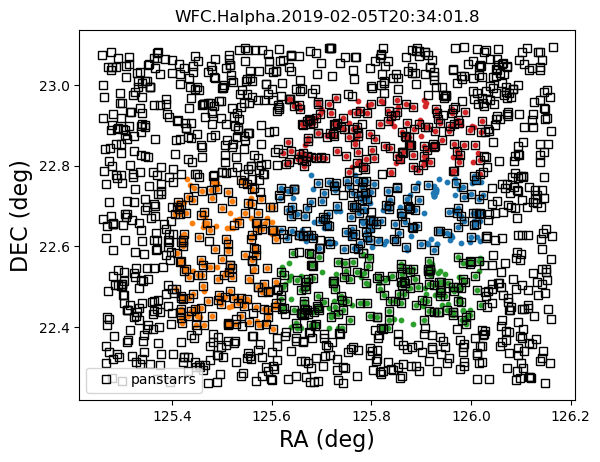

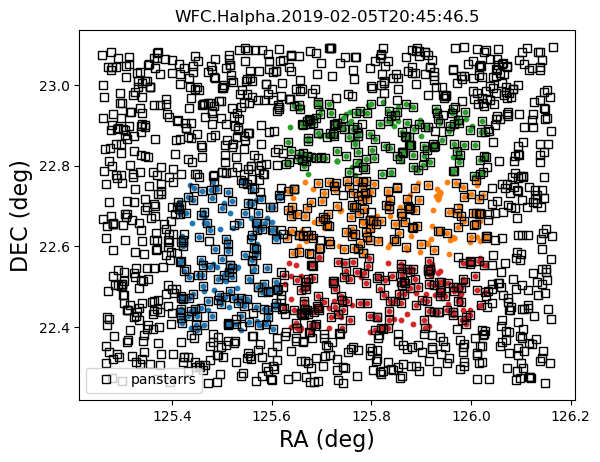

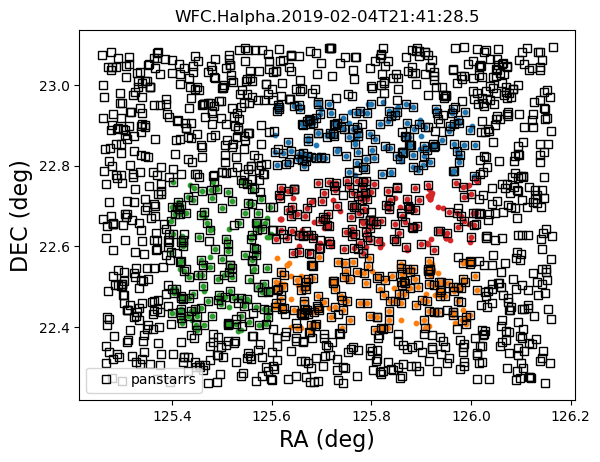

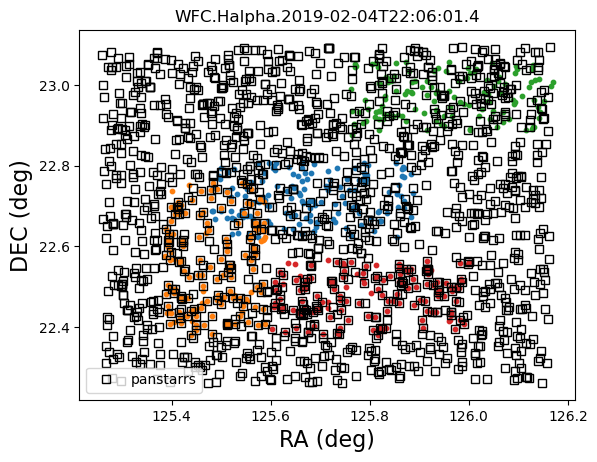

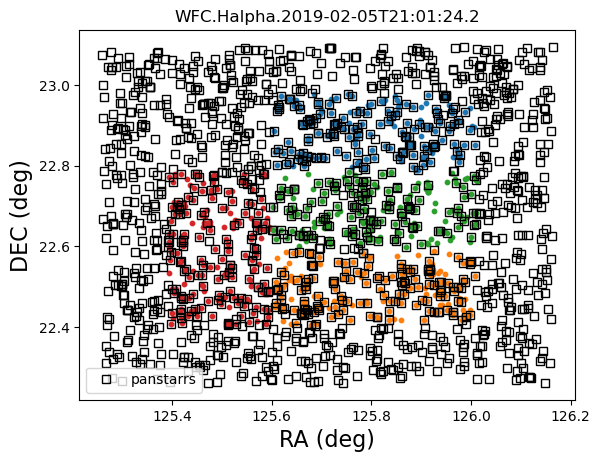

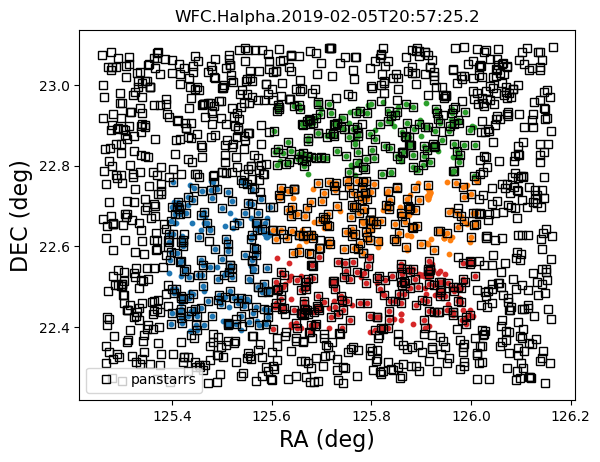

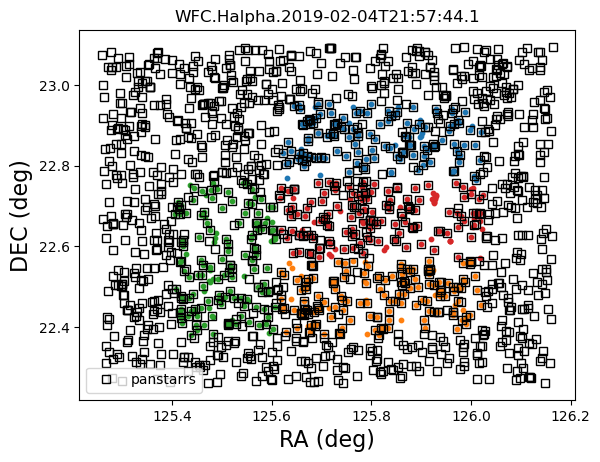

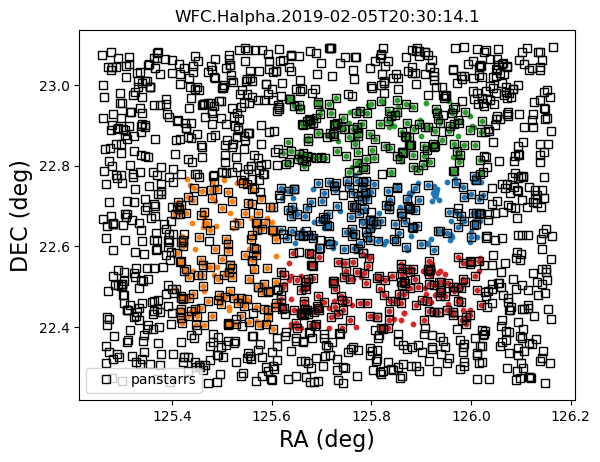

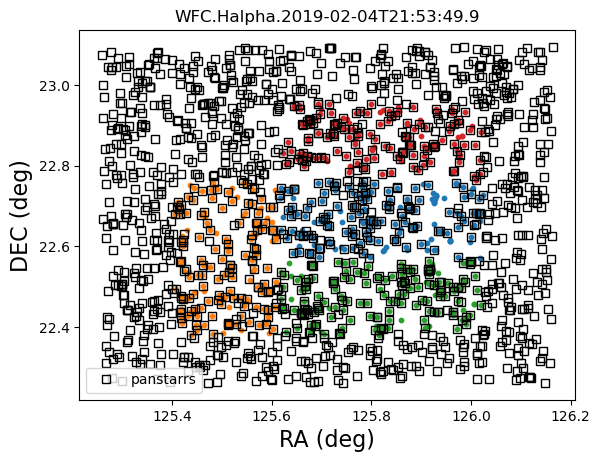

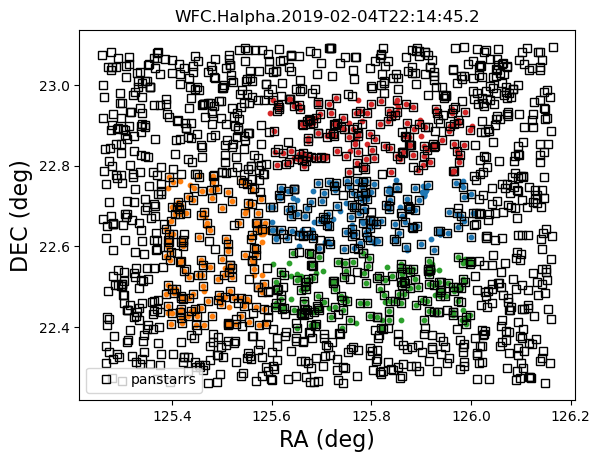

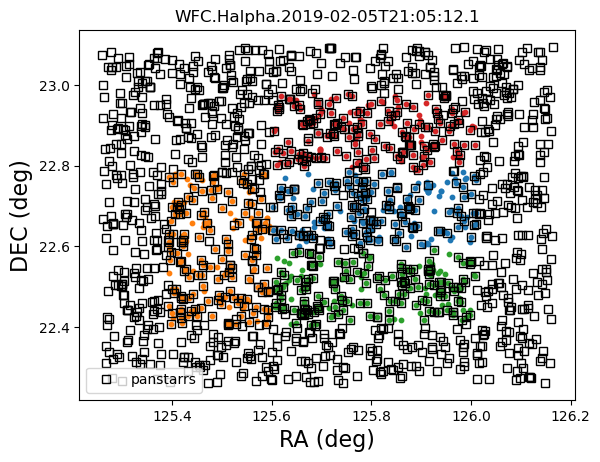

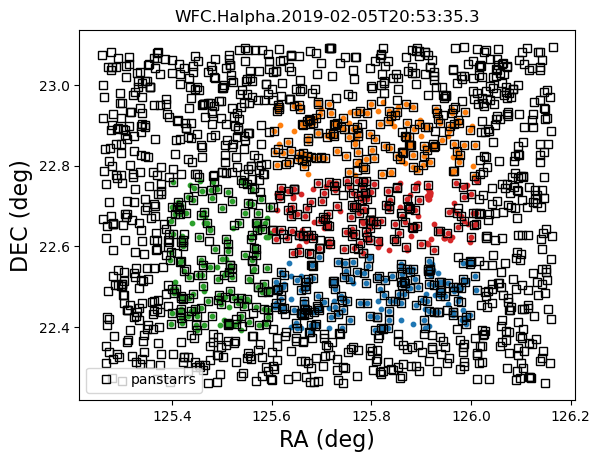

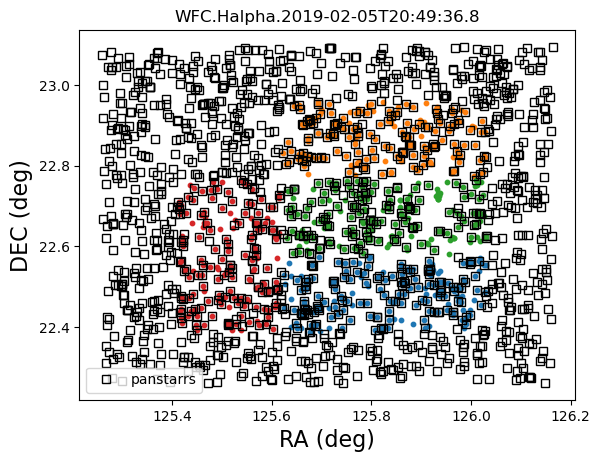

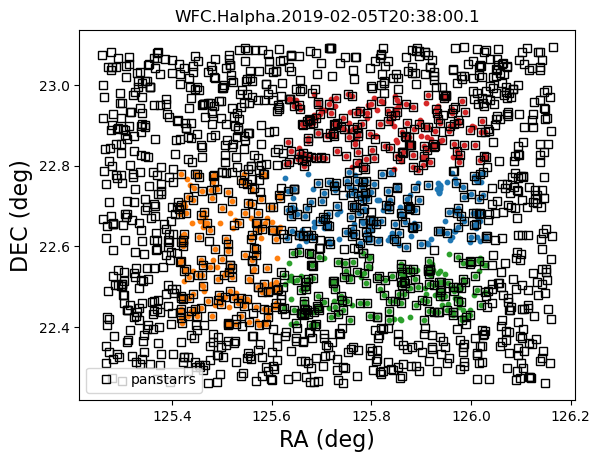

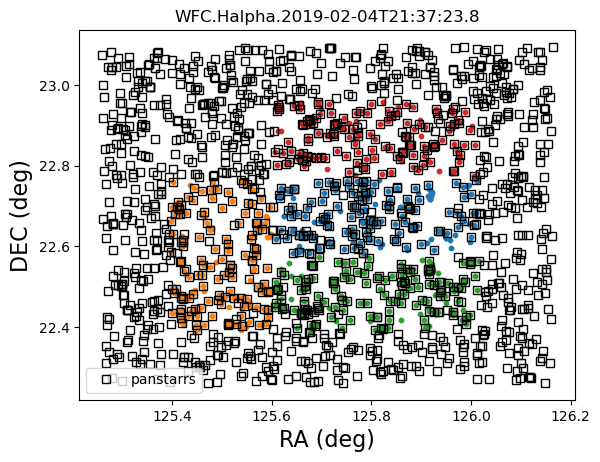

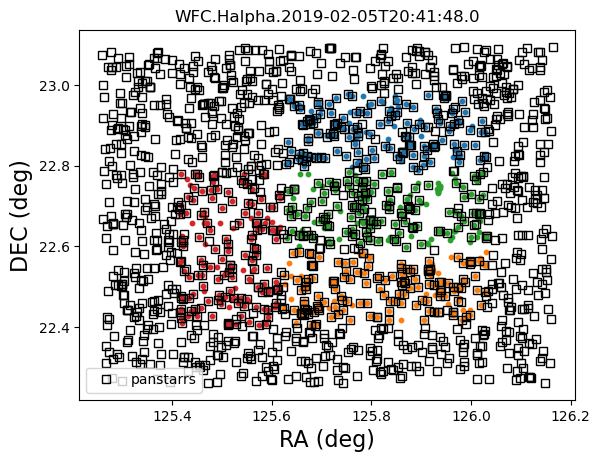

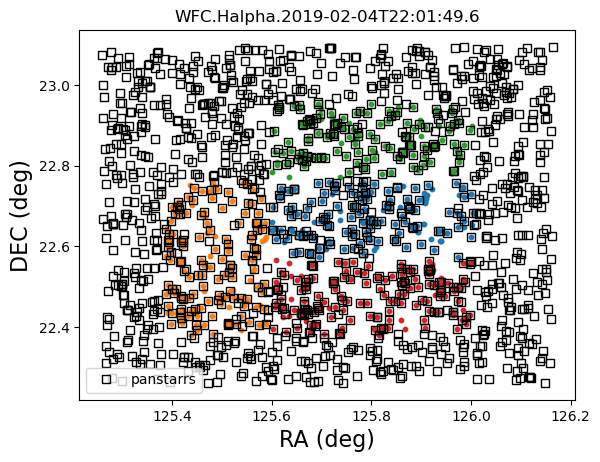

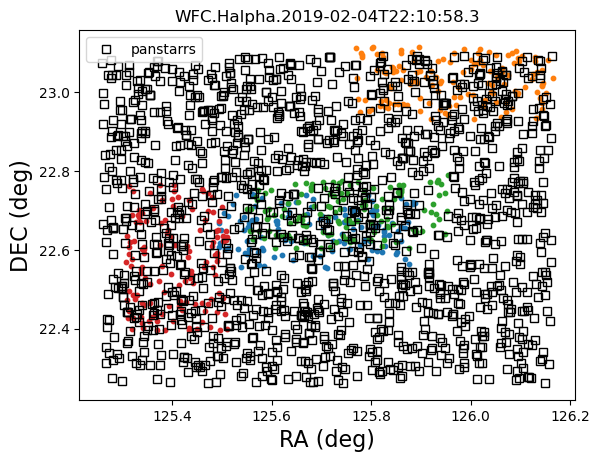

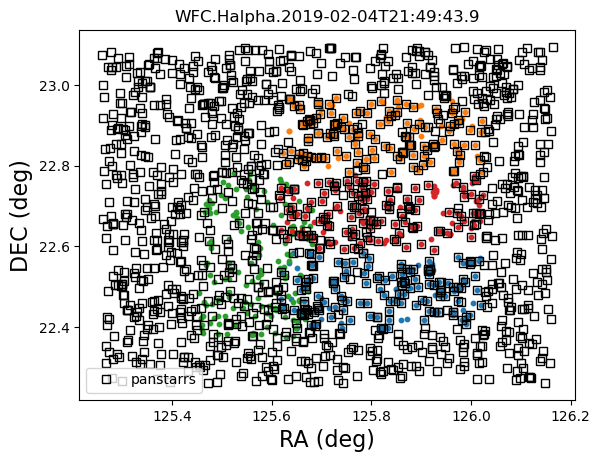

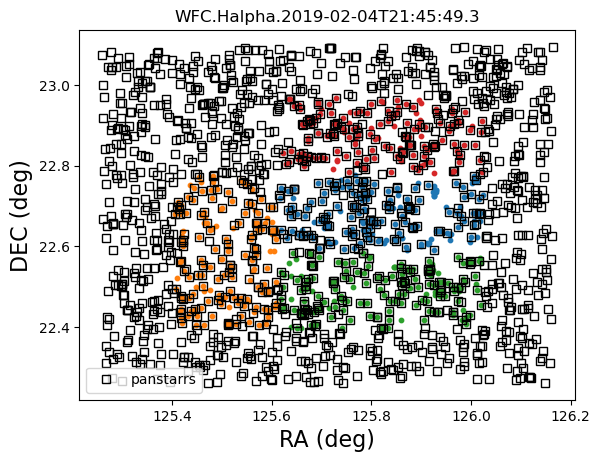

In [149]:
mycolors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_panstarrs():
    # read in panstarrs
    panfile = os.path.join(basedir,'mWFC.r._pan_tab.csv')
    #panfile = os.path.join(hdir,"WFC.r.2019-05-30T23:36:23.5_pan_tab.csv")
    pantab1 = Table.read(panfile)
    plt.plot(pantab1['RAJ2000'],pantab1['DEJ2000'],'ks',mfc='None',label="panstarrs")
    plt.legend()
    plt.xlabel("RA (deg)", fontsize=16)
    plt.ylabel("DEC (deg)", fontsize=16)
    
    
basedir = "/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019febINT-all/pointing004"
catlist = glob.glob(os.path.join(basedir,'WFC.H*.cat'))
catlist = [os.path.basename(imname) for imname in catlist]
allfilerootlist = [t.split('_')[0] for t in catlist]
#print(allfilerootlist)
filerootlist = list(set(allfilerootlist))
#print(filerootlist)
plt.close('all')
plt.figure()

for i in range(len(filerootlist)):
    image_cat_list = [m for m in catlist if filerootlist[i] in m]
    plt.figure()
    nplot=1
    for j,c in enumerate(image_cat_list):
        #print(j,nplot,c)
        tab = fits.getdata(os.path.join(basedir,c),2)
        keepflag =  (tab['FLAGS'] <  1) #& (tab['CLASS_STAR'] > 0.85)
        #print(f"{os.path.basename(c)} number of sources={len(tab)}, keepflag={np.sum(keepflag)}")
        
        plt.scatter(tab['ALPHA_J2000'],tab['DELTA_J2000'],s=10,c=mycolors[nplot-1])
        nplot += 1
    plot_panstarrs()
    plt.title(os.path.basename(filerootlist[i]))
        
    


the images have the same RA/DEC in the header, so why are the SE catalog coordinates so different?  I removed the scamp headers and reran SE. want to see what catalogs look like before running scamp.

In [150]:
!scp draco:/data-pool/Halpha/processed/2019febINT-all/pointing004/WFC.H"*".cat pointing004/.

WFC.Halpha.2019-02-04T21:37:23.8_1PA.cat      100% 1311KB   4.0MB/s   00:00    
WFC.Halpha.2019-02-04T21:37:23.8_2PA.cat      100% 1294KB   4.7MB/s   00:00    
WFC.Halpha.2019-02-04T21:37:23.8_3PA.cat      100% 1246KB   4.9MB/s   00:00    
WFC.Halpha.2019-02-04T21:37:23.8_4PA.cat      100% 1409KB   5.4MB/s   00:00    
WFC.Halpha.2019-02-04T21:41:28.5_1PA.cat      100% 1392KB   5.7MB/s   00:00    
WFC.Halpha.2019-02-04T21:41:28.5_2PA.cat      100% 1254KB   5.1MB/s   00:00    
WFC.Halpha.2019-02-04T21:41:28.5_3PA.cat      100% 1271KB   5.3MB/s   00:00    
WFC.Halpha.2019-02-04T21:41:28.5_4PA.cat      100% 1451KB   5.5MB/s   00:00    
WFC.Halpha.2019-02-04T21:45:49.3_1PA.cat      100% 1384KB   5.5MB/s   00:00    
WFC.Halpha.2019-02-04T21:45:49.3_2PA.cat      100% 1319KB   5.1MB/s   00:00    
WFC.Halpha.2019-02-04T21:45:49.3_3PA.cat      100% 1311KB   4.9MB/s   00:00    
WFC.Halpha.2019-02-04T21:45:49.3_4PA.cat      100% 1474KB   5.9MB/s   00:00    
WFC.Halpha.2019-02-04T21:49:43.9_1PA.cat

/var/folders/d_/xbzntjjj2rz0d1tfc4s267ww0000gq/T/ipykernel_92025/605088423.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<Figure size 640x480 with 0 Axes>

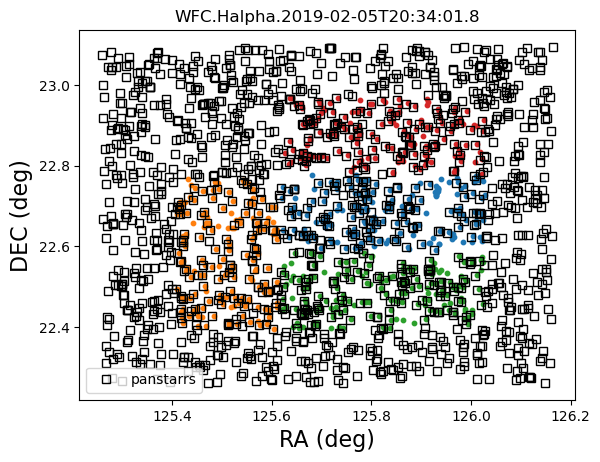

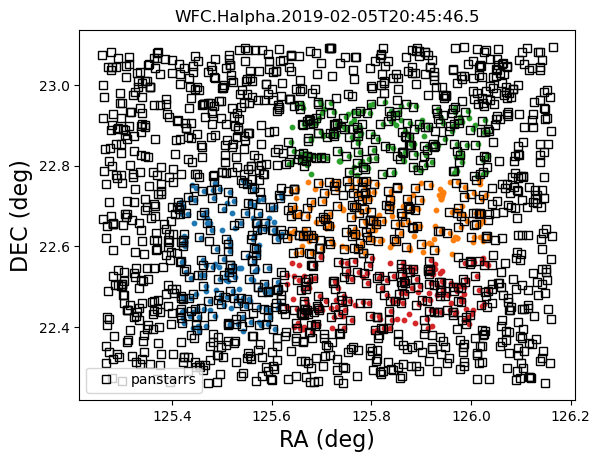

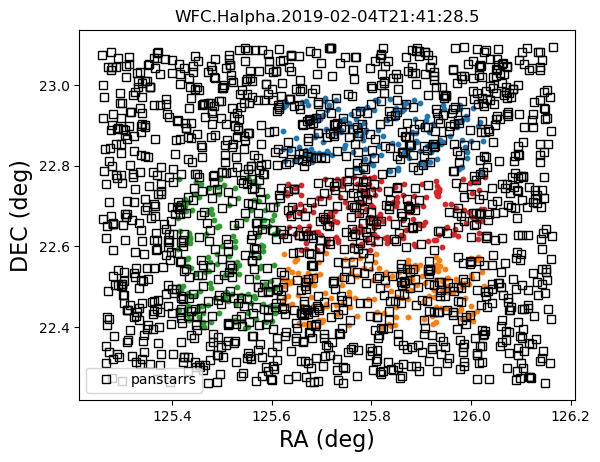

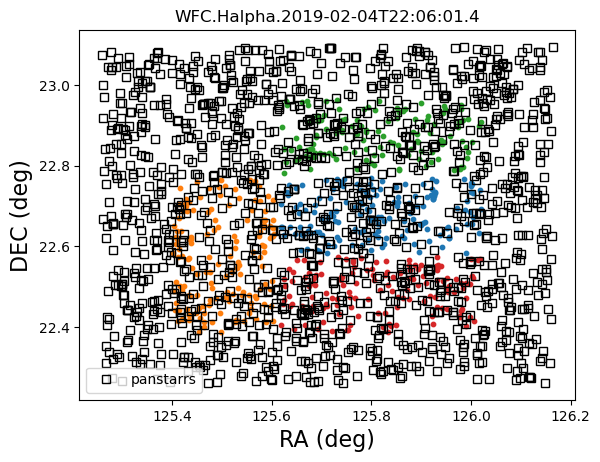

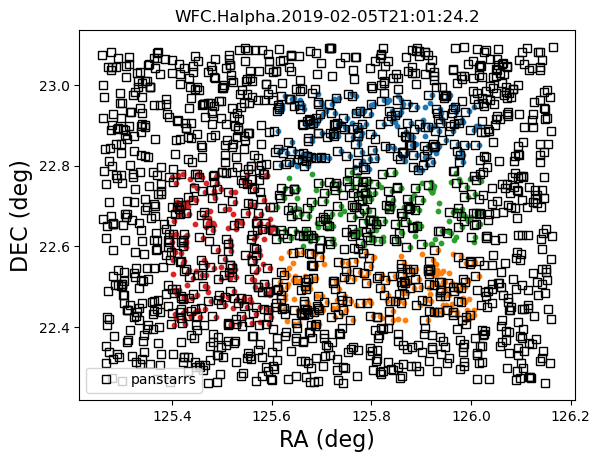

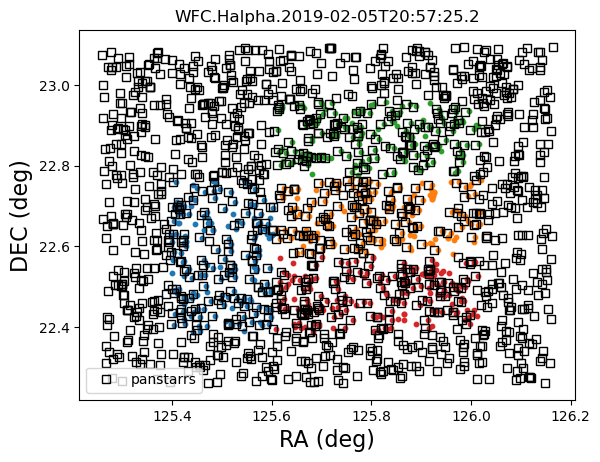

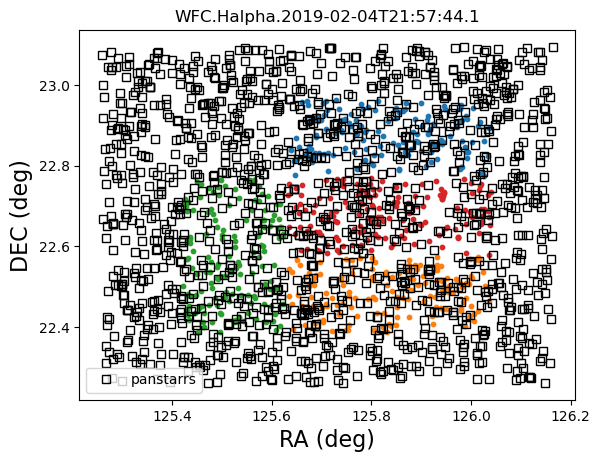

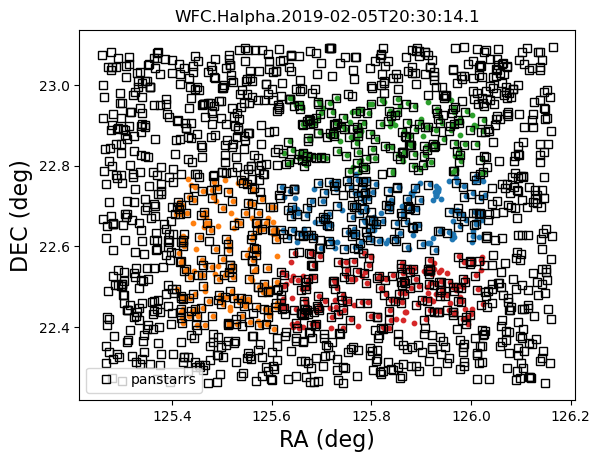

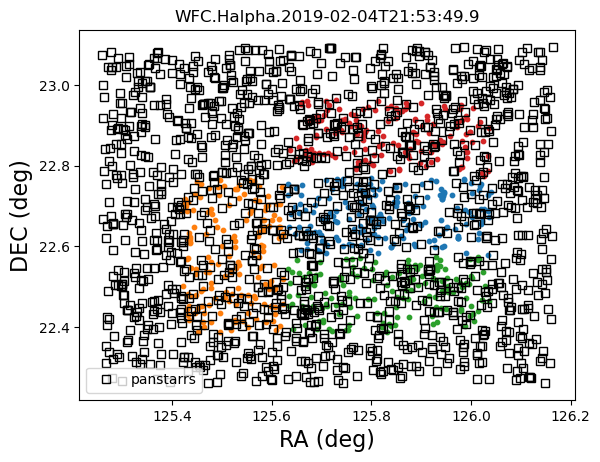

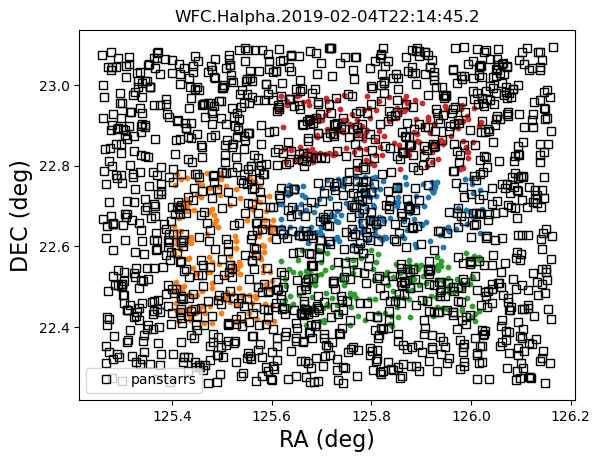

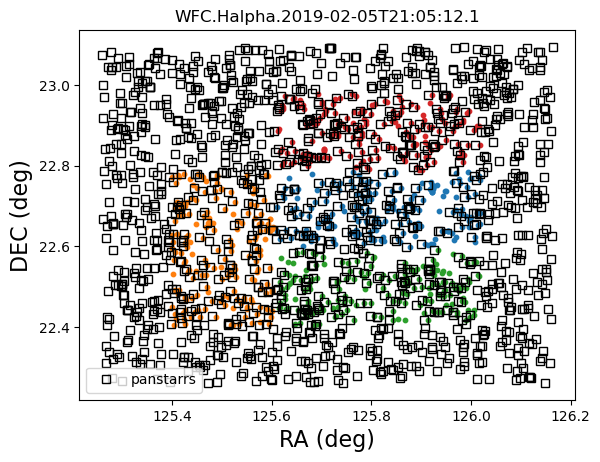

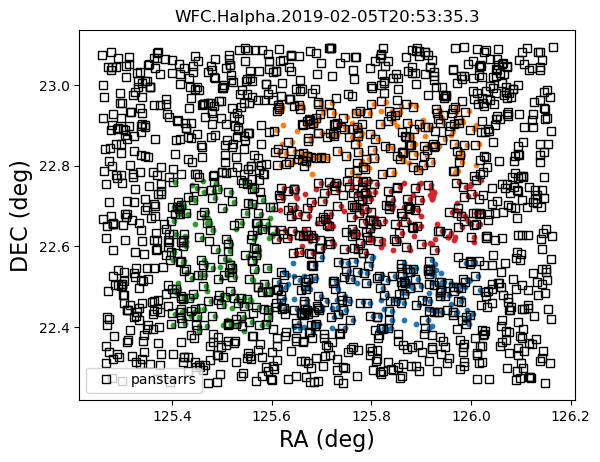

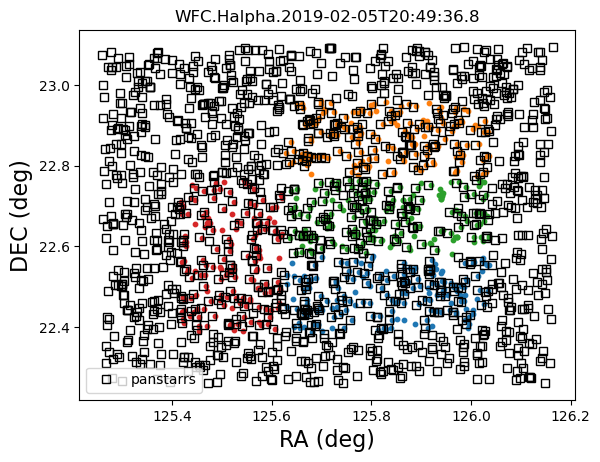

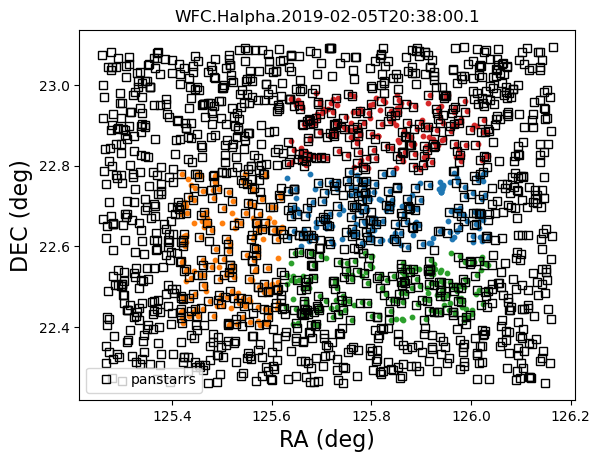

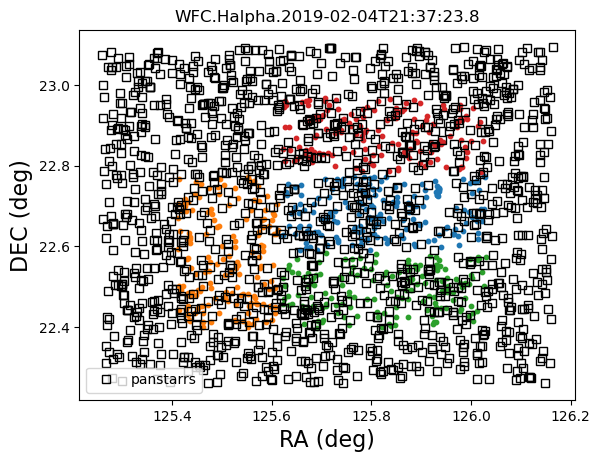

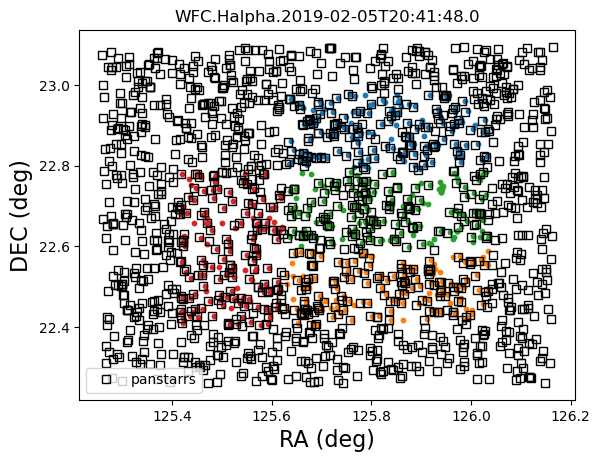

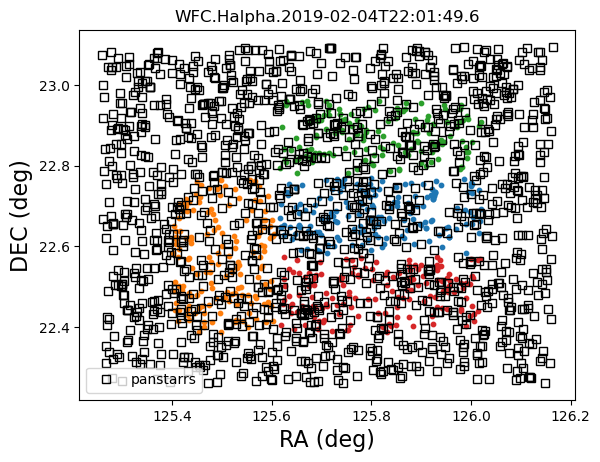

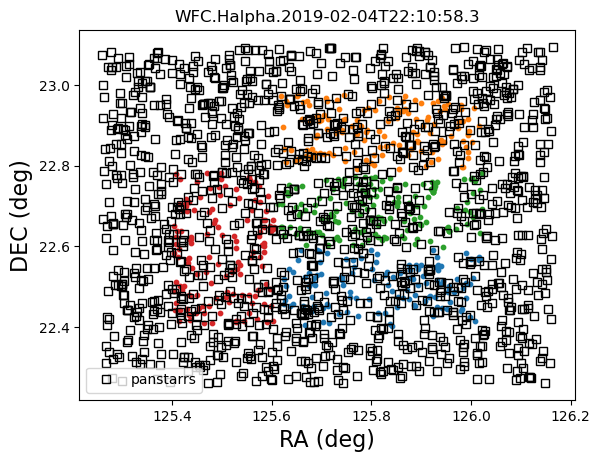

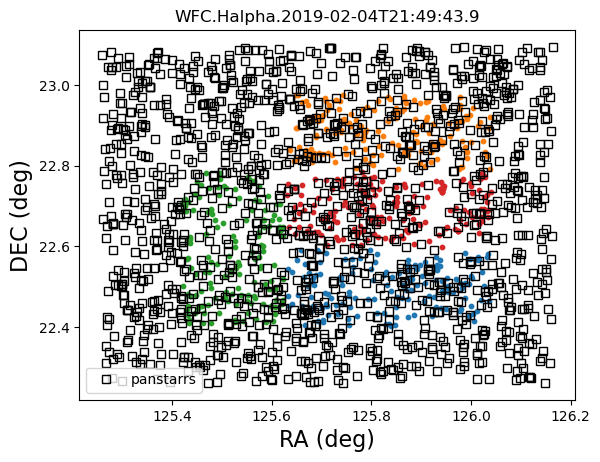

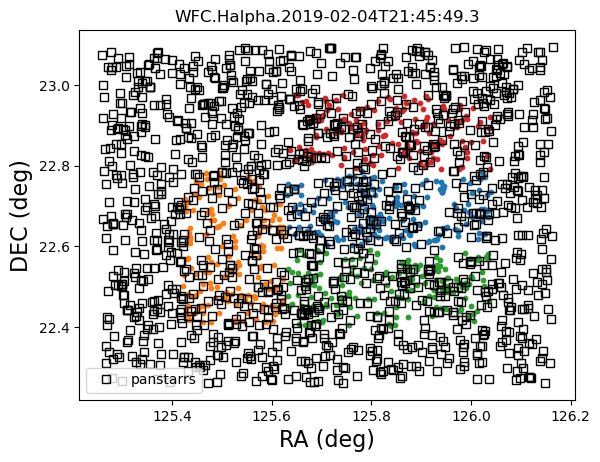

In [151]:
mycolors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_panstarrs():
    # read in panstarrs
    panfile = os.path.join(basedir,'mWFC.r._pan_tab.csv')
    #panfile = os.path.join(hdir,"WFC.r.2019-05-30T23:36:23.5_pan_tab.csv")
    pantab1 = Table.read(panfile)
    plt.plot(pantab1['RAJ2000'],pantab1['DEJ2000'],'ks',mfc='None',label="panstarrs")
    plt.legend()
    plt.xlabel("RA (deg)", fontsize=16)
    plt.ylabel("DEC (deg)", fontsize=16)
    
    
basedir = "/Users/rfinn/research/Virgo/Halpha/remaking-int-coadds-2025Dec/2019febINT-all/pointing004"
catlist = glob.glob(os.path.join(basedir,'WFC.H*.cat'))
catlist = [os.path.basename(imname) for imname in catlist]
allfilerootlist = [t.split('_')[0] for t in catlist]
#print(allfilerootlist)
filerootlist = list(set(allfilerootlist))
#print(filerootlist)
plt.close('all')
plt.figure()

for i in range(len(filerootlist)):
    image_cat_list = [m for m in catlist if filerootlist[i] in m]
    plt.figure()
    nplot=1
    for j,c in enumerate(image_cat_list):
        #print(j,nplot,c)
        tab = fits.getdata(os.path.join(basedir,c),2)
        keepflag =  (tab['FLAGS'] <  1) #& (tab['CLASS_STAR'] > 0.85)
        #print(f"{os.path.basename(c)} number of sources={len(tab)}, keepflag={np.sum(keepflag)}")
        
        plt.scatter(tab['ALPHA_J2000'],tab['DELTA_J2000'],s=10,c=mycolors[nplot-1])
        nplot += 1
    plot_panstarrs()
    plt.title(os.path.basename(filerootlist[i]))
        
    
